# Time Evolution of Quantum Spin Chains: Exact Diagonalisation and Qiskit Trotter Simulation

**Course:** PH10110 - Quantum Computing Group Project  
**Date:** March 2026  

---

## Abstract

We study the real-time dynamics of the one-dimensional anisotropic Heisenberg (XXZ) spin chain
by comparing three simulation strategies of increasing realism:
(i) exact sparse-matrix time evolution via the matrix exponential,
(ii) ideal first- and second-order Qiskit Trotter-Suzuki circuits simulated with `Statevector`, and
(iii) noisy Qiskit Trotter circuits simulated with `AerSimulator` in density-matrix mode.
For an $L = 8$ site chain with open boundary conditions, we characterise
the space-time magnetisation dynamics and the two-dimensional Fourier spectrum of the
$\langle Z_i(t)\rangle$ observable. We quantify the Trotter approximation error as a function
of the number of time steps, confirming the expected $\mathcal{O}(\Delta t^p)$ convergence
for $p$-th order product formulas. The noisy Aer simulations demonstrate that modest Pauli-type
gate noise significantly degrades the long-time fidelity of the evolution, illustrating both the
utility of quantum-circuit simulation and the current sensitivity of many-body dynamics to noise.

## Table of Contents

1. [Introduction](#1-introduction)
2. [Problem Formulation and Theoretical Background](#2-problem-formulation-and-theoretical-background)
3. [Methods](#3-methods)
4. [Implementation Details](#4-implementation-details)
5. [Classical Benchmarks: Exact Diagonalisation](#5-classical-benchmarks-exact-diagonalisation)
6. [Quantum Simulation Results: Trotter Decomposition](#6-quantum-simulation-results-trotter-decomposition)
7. [Noisy Simulation Results](#7-noisy-simulation-results)
8. [Error Scaling Analysis](#8-error-scaling-analysis)
9. [Spectral Analysis](#9-spectral-analysis)
10. [Discussion](#10-discussion)
11. [Conclusion](#11-conclusion)
12. [Contribution Statement](#12-contribution-statement)
13. [References](#13-references)

## 1. Introduction

<a id="1-introduction"></a>

Simulating the time evolution of quantum many-body systems is one of the most promising
near-term applications of quantum computing [1, 2]. The central difficulty is that the
Hilbert-space dimension grows exponentially with the number of particles: for $L$ spin-$\tfrac{1}{2}$
sites the state vector has $2^L$ complex amplitudes, making classical simulation intractable
beyond $L \approx 40$-50 even on modern supercomputers.

Quantum computers bypass this exponential barrier by encoding the $2^L$-dimensional state
in only $L$ qubits. Feynman's original insight [3] was precisely that a controllable quantum
system could simulate another quantum system efficiently. Since then, Lloyd showed that
local Hamiltonians can be simulated in polynomial time using product-formula (Trotter)
decompositions [4], and this remains one of the best-understood quantum-simulation
algorithms.

**The physical system** we study is the one-dimensional XXZ Heisenberg spin chain, a
paradigmatic model in condensed-matter physics that captures the competition between
exchange interactions and Ising anisotropy. It exhibits a rich phase diagram including
gapless Luttinger-liquid, ferromagnetic, and antiferromagnetic Neel phases depending on the
anisotropy parameter $J_z$.

**Project objective.** The aim of this project is threefold:

1. **Benchmark exact classical simulation** of the XXZ model for $L = 8$ spins, including
   space-time magnetisation maps and spectral analysis.
2. **Implement and validate Qiskit Trotter-Suzuki circuits** for the time-evolution operator,
   comparing first- and second-order product formulae against exact results.
3. **Assess the impact of gate-level noise** by simulating the same Trotter circuits with a
   Qiskit Aer noise model, and comparing the noisy circuit dynamics to both the exact and ideal
   quantum-circuit results.

By comparing these three levels of simulation we can draw conclusions about when quantum
hardware-inspired circuit models capture the correct many-body dynamics, and where noise
becomes the dominant limitation.

**Why quantum computers are relevant.** For $L = 8$, exact classical simulation is
straightforward (the Hilbert space has dimension $2^8 = 256$), so there is no quantum
advantage at this system size. The value of this study is pedagogical and methodological:
we validate the quantum algorithms at a size where exact benchmarking is possible, before
extrapolating to the $L \gtrsim 50$ regime where classical methods fail and quantum
advantage becomes genuine. We discuss the scaling implications in Section 10.

## 2. Problem Formulation and Theoretical Background

<a id="2-problem-formulation-and-theoretical-background"></a>

### 2.1 The XXZ Heisenberg Hamiltonian

The one-dimensional XXZ model on $L$ sites with open boundary conditions reads

$$
H = -\sum_{\langle i,j \rangle}
    \bigl(\sigma_i^x \sigma_j^x + \sigma_i^y \sigma_j^y + J_z\,\sigma_i^z \sigma_j^z\bigr),
\tag{1}
$$

where $\sigma_i^\alpha$ ($\alpha \in \{x,y,z\}$) are the Pauli matrices acting on site $i$,
and the sum runs over nearest-neighbour pairs $\langle i,j \rangle$.  The dimensionless
coupling $J_z$ controls the Ising anisotropy:

| Regime | $J_z$ range | Physical character |
|--------|-------------|--------------------|
| Ferromagnetic | $J_z > 1$ | Ising-like, spins prefer alignment |
| Isotropic (XXX) | $J_z = 1$ | Full $SU(2)$ symmetry |
| Critical (XY-like) | $-1 < J_z < 1$ | Gapless Luttinger liquid |
| Antiferromagnetic Néel | $J_z < -1$ | Alternating spin order |

In this project we study three representative cases:

- **Case A:** $J_z = 1.5$ (ferromagnetic), initial state all spins down ($|00\ldots 0\rangle$) with one spin rotated to the equator.
- **Case B:** $J_z = 1.5$ (ferromagnetic), initial state all spins up ($|11\ldots 1\rangle$) with one spin rotated.
- **Case C:** $J_z = -1.5$ (antiferromagnetic Néel), alternating initial state ($|1010\ldots\rangle$) with one spin rotated.

### 2.2 Time Evolution

The state of the system at time $t$ is given by the Schrödinger-picture evolution

$$
|\psi(t)\rangle = e^{-iHt}\,|\psi(0)\rangle,
\tag{2}
$$

where we set $\hbar = 1$.  Computing $e^{-iHt}$ exactly requires diagonalising the $2^L \times 2^L$
Hamiltonian matrix, which costs $\mathcal{O}(2^{3L})$ in general.  For sparse Hamiltonians
the Krylov-subspace method `expm_multiply` from SciPy provides an efficient alternative
that avoids explicit diagonalisation [5].

### 2.3 Initial-State Preparation

Each simulation case starts from a product state (a computational basis state) with a
single-site rotation that creates a local superposition.  For a site initially in $|0\rangle$,
we apply

$$
|\psi_{\mathrm{site}}\rangle = R_z(\phi)\,H\,|0\rangle
    = R_z(\phi)\,|+\rangle
    = \frac{1}{\sqrt{2}}\bigl(e^{-i\phi/2}|0\rangle + e^{+i\phi/2}|1\rangle\bigr),
\tag{3}
$$

with $\phi = \pi/3$.  This places the spin on the Bloch-sphere equator, breaking the $Z$
symmetry and generating non-trivial dynamics under $H$.

### 2.4 Observables

We track the local expectation values $\langle\sigma_i^\alpha(t)\rangle$ for
$\alpha \in \{X, Y, Z\}$ and all sites $i \in \{0, \ldots, L-1\}$.  These define a
space–time observable map of dimension $(n_t \times L \times 3)$.

The two-dimensional discrete Fourier transform of $\langle Z_i(t)\rangle$ yields the
momentum–frequency spectrum, allowing identification of the dispersion relation and
collective excitations of the spin chain.

## 3. Methods

<a id="3-methods"></a>

### 3.1 Exact Diagonalisation (Classical Benchmark)

For $L = 8$ the Hamiltonian is a $256 \times 256$ sparse matrix. We construct it
by summing two-site Kronecker-product terms (Eq. 1) and compute the time-evolved states
using SciPy's Krylov-based `expm_multiply`, which evaluates $e^{-iHt}|\psi_0\rangle$
without forming the full dense exponential. This serves as our ground-truth benchmark.

The computational cost scales as $\mathcal{O}(2^L \cdot \mathrm{nnz}(H))$ per time step,
where $\mathrm{nnz}(H)$ is the number of non-zero elements. For local Hamiltonians
$\mathrm{nnz}(H) = \mathcal{O}(L \cdot 2^L)$, giving an overall cost of
$\mathcal{O}(L \cdot 4^L)$ per time step - exponential in $L$.

### 3.2 Trotter-Suzuki Decomposition in Qiskit

The product-formula approach approximates the global evolution operator by splitting
it into a sequence of local two-site unitaries. Writing $H = \sum_b H_b$ where
$b$ labels nearest-neighbour bonds, we have:

**First-order Trotter:**
$$
e^{-iH\Delta t} \approx \prod_{b} e^{-iH_b\Delta t} + \mathcal{O}(\Delta t^2).
\tag{4}
$$

**Second-order (symmetric) Trotter:**
$$
e^{-iH\Delta t} \approx
    \prod_{b}^{\rightarrow} e^{-iH_b\Delta t/2}
    \prod_{b}^{\leftarrow} e^{-iH_b\Delta t/2}
    + \mathcal{O}(\Delta t^3).
\tag{5}
$$

In our Qiskit implementation, each XXZ two-site factor is decomposed explicitly into
native `rxx`, `ryy`, and `rzz` gates. The second-order formula is symmetric under time
reversal, which removes the leading error term and gives substantially better accuracy for
fixed step size.

**Why Trotter decomposition is appropriate:** it is the simplest product-formula method,
well-understood theoretically, and directly expressible as a quantum circuit. Its error is
controllable: by increasing the number of Trotter steps $n$ (decreasing $\Delta t = T/n$),
the approximation converges to the exact evolution.

### 3.3 Noisy Qiskit Aer Simulation

To model the effect of imperfect circuit execution, we simulate the same Trotter circuits with
`AerSimulator(method="density_matrix")` and a Pauli-type noise model. After each primitive
gate in the Trotter circuit, every affected qubit undergoes

- an $X$ error with probability $p_X$,
- a $Z$ error with probability $p_Z$,
- or the identity with probability $1 - p_X - p_Z$.

For two-qubit gates, the same single-qubit Pauli channel is applied independently to both
participating qubits. In the notebook implementation below, the initial many-body state is
injected exactly and the Aer noise acts on the Trotter evolution circuit, so the comparison
isolates dynamical gate noise rather than state-preparation error.

The noisy simulation is performed deterministically in density-matrix form rather than by Monte
Carlo trajectory averaging, so the output directly gives the noisy expectation values
$\langle X_i(t)\rangle$, $\langle Y_i(t)\rangle$, and $\langle Z_i(t)\rangle$.

## 4. Implementation Details

<a id="4-implementation-details"></a>

The repository contains reusable Python modules, but to satisfy the project requirement that the
final report should contain all code needed to reproduce the results, this notebook is made
**self-contained**. The helper code cell below includes the minimal implementations required for
all figures and tables in the report:

- exact classical XXZ Hamiltonian construction and sparse-matrix evolution;
- consistent initial-state preparation for all cases;
- ideal Qiskit Trotter circuits using `Statevector` simulation;
- noisy Qiskit Aer Trotter circuits using density-matrix simulation;
- observable extraction, error metrics, and FFT analysis.

The classical helper functions mirror the logic of `spin_chain.py`, while the quantum-circuit
helper functions mirror the Qiskit implementation in `qc.py`. The notebook does **not** depend on
`project_pipeline.py`, so the report can be executed start-to-finish without importing the earlier
NumPy-based Trotter prototype.

Key design choices:
- **Sparse matrices** (SciPy CSR format) for the exact Hamiltonian, keeping classical benchmark costs manageable for $L = 8$.
- **A consistent initial-state definition** shared by the exact, ideal-Qiskit, and noisy-Qiskit pipelines.
- **Explicit Trotter gate decomposition** into `rxx`, `ryy`, and `rzz` so the circuit structure is transparent.
- **Aer density-matrix simulation** for the noisy circuit results, avoiding shot noise and giving direct access to expectation values.

Below we import the required libraries, check the Qiskit/Aer environment, and define the self-contained helper functions used throughout the report.

In [1]:
import io

import matplotlib
matplotlib.use("agg")
import matplotlib.pyplot as plt
import qiskit
import qiskit_aer
from IPython.display import Image, display

print(f"qiskit version: {qiskit.__version__}")
print(f"qiskit-aer version: {qiskit_aer.__version__}")

# Mirrored helper code from GroupProject/time_evolution/spin_chain.py

from dataclasses import dataclass
from typing import Iterable, Literal

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

Boundary = Literal["open", "periodic"]


def pauli_dense() -> dict[str, np.ndarray]:
    i2 = np.eye(2, dtype=np.complex128)
    x = np.array([[0, 1], [1, 0]], dtype=np.complex128)
    y = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
    z = np.array([[1, 0], [0, -1]], dtype=np.complex128)
    h = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=np.complex128)
    return {"I": i2, "X": x, "Y": y, "Z": z, "H": h}


def rz_dense(phi: float) -> np.ndarray:
    return np.array(
        [[np.exp(-1j * phi / 2), 0], [0, np.exp(1j * phi / 2)]],
        dtype=np.complex128,
    )


def equator_unitary_from_zero(phi: float) -> np.ndarray:
    p = pauli_dense()
    return rz_dense(phi) @ p["H"]


def basis_state(bitstring: str) -> np.ndarray:
    if any(ch not in "01" for ch in bitstring):
        raise ValueError("bitstring must contain only '0'/'1'")
    dim = 2 ** len(bitstring)
    index = int(bitstring, 2) if bitstring else 0
    state = np.zeros((dim,), dtype=np.complex128)
    state[index] = 1.0
    return state


def _as_sparse(op: np.ndarray) -> sp.csr_matrix:
    return sp.csr_matrix(op, dtype=np.complex128)


def kron_all_sparse(ops: Iterable[sp.spmatrix]) -> sp.csr_matrix:
    ops = list(ops)
    if not ops:
        raise ValueError("ops must be non-empty")
    out = ops[0].tocsr()
    for op in ops[1:]:
        out = sp.kron(out, op, format="csr")
    return out


def two_site_term_sparse(
    op_i: sp.spmatrix, i: int, op_j: sp.spmatrix, j: int, L: int
) -> sp.csr_matrix:
    if not (0 <= i < L and 0 <= j < L):
        raise ValueError("site index out of range")
    if i == j:
        raise ValueError("i and j must be different sites")
    i2 = sp.identity(2, dtype=np.complex128, format="csr")
    ops: list[sp.spmatrix] = [i2] * L
    ops[i] = op_i
    ops[j] = op_j
    return kron_all_sparse(ops)


def xxz_hamiltonian_sparse(L: int, Jz: float, boundary: Boundary = "open") -> sp.csr_matrix:
    if L <= 0:
        raise ValueError("L must be positive")
    if boundary not in ("open", "periodic"):
        raise ValueError("boundary must be 'open' or 'periodic'")

    p = pauli_dense()
    x = _as_sparse(p["X"])
    y = _as_sparse(p["Y"])
    z = _as_sparse(p["Z"])

    if boundary == "open":
        pairs = [(i, i + 1) for i in range(L - 1)]
    else:
        pairs = [(i, (i + 1) % L) for i in range(L)]

    dim = 2**L
    H = sp.csr_matrix((dim, dim), dtype=np.complex128)

    for i, j in pairs:
        H = H - two_site_term_sparse(x, i, x, j, L)
        H = H - two_site_term_sparse(y, i, y, j, L)
        H = H - (Jz * two_site_term_sparse(z, i, z, j, L))

    return H


def apply_single_qubit_unitary(
    state: np.ndarray, U: np.ndarray, site: int, L: int
) -> np.ndarray:
    if state.shape != (2**L,):
        raise ValueError("state shape must be (2**L,)")
    if U.shape != (2, 2):
        raise ValueError("U must be a 2x2 matrix")
    if not (0 <= site < L):
        raise ValueError("site index out of range")

    tensor = state.reshape((2,) * L)
    tensor = np.moveaxis(tensor, site, 0)  # (2, ...)
    tensor = np.tensordot(U, tensor, axes=([1], [0]))  # (2, ...)
    tensor = np.moveaxis(tensor, 0, site)
    return tensor.reshape((2**L,))


def local_expectation(state: np.ndarray, op: np.ndarray, site: int, L: int) -> complex:
    if state.shape != (2**L,):
        raise ValueError("state shape must be (2**L,)")
    if op.shape != (2, 2):
        raise ValueError("op must be a 2x2 matrix")
    if not (0 <= site < L):
        raise ValueError("site index out of range")

    ket = state.reshape((2,) * L)
    ket = np.moveaxis(ket, site, 0)
    ket = np.tensordot(op, ket, axes=([1], [0]))
    ket = np.moveaxis(ket, 0, site)
    return np.vdot(state, ket.reshape((2**L,)))


def evolve_states_expm_multiply(
    H: sp.spmatrix, state0: np.ndarray, times: np.ndarray
) -> np.ndarray:
    times = np.asarray(times, dtype=float)
    if times.ndim != 1:
        raise ValueError("times must be a 1D array")

    A = (-1j) * H

    if len(times) == 0:
        return np.zeros((0, state0.size), dtype=np.complex128)

    if len(times) == 1:
        return np.asarray([expm_multiply(A * times[0], state0)], dtype=np.complex128)

    dt = times[1] - times[0]
    grid = times[0] + dt * np.arange(len(times), dtype=float)
    if np.allclose(times, grid, rtol=0, atol=1e-12):
        states = expm_multiply(A, state0, start=times[0], stop=times[-1], num=len(times), endpoint=True)
        return np.asarray(states, dtype=np.complex128)

    out = np.empty((len(times), state0.size), dtype=np.complex128)
    for idx, t in enumerate(times):
        out[idx] = expm_multiply(A * t, state0)
    return out


@dataclass(frozen=True)
class SimulationConfig:
    L: int
    Jz: float
    boundary: Boundary = "open"
    phi: float = 0.0
    rotate_site: int | None = None


def initial_state_from_config(cfg: SimulationConfig) -> np.ndarray:
    if cfg.L <= 0:
        raise ValueError("L must be positive")
    # Default: all spins down |0>^{\otimes L}
    bitstring = "0" * cfg.L
    state = basis_state(bitstring)

    site = cfg.rotate_site if cfg.rotate_site is not None else (cfg.L // 2)
    U = equator_unitary_from_zero(cfg.phi)
    return apply_single_qubit_unitary(state, U, site=site, L=cfg.L)

# Mirrored helper code from GroupProject/time_evolution/qc.py
from dataclasses import dataclass
from typing import TYPE_CHECKING, Literal

import numpy as np

Boundary = Literal["open", "periodic"]
InitPattern = Literal["all0", "all1", "alternating10"]

if TYPE_CHECKING:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import DensityMatrix, SparsePauliOp, Statevector
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel


def _import_qiskit() -> tuple[
    type["QuantumCircuit"],
    type["Statevector"],
    type["SparsePauliOp"],
    type["DensityMatrix"],
]:
    try:
        from qiskit import QuantumCircuit
        from qiskit.quantum_info import DensityMatrix, SparsePauliOp, Statevector
    except ImportError as exc:  # pragma: no cover - only triggered when qiskit missing
        raise ImportError(
            "qiskit is required for GroupProject.time_evolution.qc. "
            "Install it with: pip install qiskit"
        ) from exc
    return QuantumCircuit, Statevector, SparsePauliOp, DensityMatrix


def _import_qiskit_aer() -> tuple[type["AerSimulator"], type["NoiseModel"], object]:
    try:
        from qiskit_aer import AerSimulator
        from qiskit_aer.noise import NoiseModel, pauli_error
    except ImportError as exc:  # pragma: no cover - only triggered when qiskit-aer missing
        raise ImportError(
            "qiskit-aer is required for noisy Qiskit simulation. "
            "Install it with: pip install qiskit-aer"
        ) from exc
    return AerSimulator, NoiseModel, pauli_error


def _site_to_qubit(site: int, L: int) -> int:
    if not (0 <= site < L):
        raise ValueError("site index out of range")
    return L - 1 - site


def build_initial_bitstring(L: int, init_pattern: InitPattern) -> str:
    if L <= 0:
        raise ValueError("L must be positive")
    if init_pattern == "all0":
        return "0" * L
    if init_pattern == "all1":
        return "1" * L
    if init_pattern == "alternating10":
        if L % 2 != 0:
            raise ValueError("alternating10 requires even L")
        return "10" * (L // 2)
    raise ValueError(f"unknown init_pattern: {init_pattern}")


def build_bonds(L: int, boundary: Boundary) -> list[tuple[int, int]]:
    if L <= 1:
        raise ValueError("L must be at least 2")
    if boundary == "open":
        raw = [(i, i + 1) for i in range(L - 1)]
    elif boundary == "periodic":
        raw = [(i, (i + 1) % L) for i in range(L)]
    else:
        raise ValueError("boundary must be 'open' or 'periodic'")

    bonds: list[tuple[int, int]] = []
    for i, j in raw:
        a, b = (i, j) if i < j else (j, i)
        if (a, b) not in bonds:
            bonds.append((a, b))
    return bonds


@dataclass(frozen=True)
class QiskitSimulationConfig:
    L: int
    Jz: float
    boundary: Boundary = "open"
    init_pattern: InitPattern = "all0"
    phi: float = 0.0
    rotate_site: int | None = None


def build_initial_circuit(
    L: int,
    init_pattern: InitPattern,
    phi: float,
    rotate_site: int | None = None,
) -> tuple["QuantumCircuit", str, int]:
    QuantumCircuit, _, _, _ = _import_qiskit()

    bitstring = build_initial_bitstring(L=L, init_pattern=init_pattern)
    site = rotate_site if rotate_site is not None else (L // 2)
    if not (0 <= site < L):
        raise ValueError("rotate_site out of range")

    qc = QuantumCircuit(L)

    for site_idx, bit in enumerate(bitstring):
        if bit == "1":
            qc.x(_site_to_qubit(site_idx, L))

    q = _site_to_qubit(site, L)
    if bitstring[site] == "0":
        qc.h(q)
        qc.rz(phi, q)
    else:
        qc.x(q)
        qc.h(q)
        qc.rz(phi, q)

    return qc, bitstring, site


def initial_statevector(
    L: int,
    init_pattern: InitPattern,
    phi: float,
    rotate_site: int | None = None,
) -> tuple[np.ndarray, str, int]:
    _, Statevector, _, _ = _import_qiskit()
    init_circuit, bitstring, site = build_initial_circuit(
        L=L, init_pattern=init_pattern, phi=phi, rotate_site=rotate_site
    )
    state = Statevector.from_instruction(init_circuit)
    return np.asarray(state.data, dtype=np.complex128), bitstring, site


def append_xxz_two_site_evolution(
    circuit: "QuantumCircuit",
    i: int,
    j: int,
    dt: float,
    Jz: float,
    L: int,
) -> None:
    if i == j:
        raise ValueError("two-site term requires i != j")
    qi = _site_to_qubit(i, L)
    qj = _site_to_qubit(j, L)

    circuit.rxx(-2.0 * dt, qi, qj)
    circuit.ryy(-2.0 * dt, qi, qj)
    circuit.rzz(-2.0 * Jz * dt, qi, qj)


def append_trotter_interval(
    circuit: "QuantumCircuit",
    L: int,
    Jz: float,
    dt: float,
    boundary: Boundary = "open",
    order: int = 2,
) -> None:
    if order not in (1, 2):
        raise ValueError("order must be 1 or 2")
    if L <= 1:
        raise ValueError("L must be at least 2")

    bonds = build_bonds(L=L, boundary=boundary)
    if order == 1:
        for i, j in bonds:
            append_xxz_two_site_evolution(circuit, i=i, j=j, dt=dt, Jz=Jz, L=L)
        return

    half = 0.5 * dt
    for i, j in bonds:
        append_xxz_two_site_evolution(circuit, i=i, j=j, dt=half, Jz=Jz, L=L)
    for i, j in reversed(bonds):
        append_xxz_two_site_evolution(circuit, i=i, j=j, dt=half, Jz=Jz, L=L)


def build_time_evolution_circuit(
    cfg: QiskitSimulationConfig,
    t_final: float,
    n_steps: int,
    order: int = 2,
) -> tuple["QuantumCircuit", str, int]:
    if n_steps < 0:
        raise ValueError("n_steps must be non-negative")

    init_circuit, bitstring, site = build_initial_circuit(
        L=cfg.L,
        init_pattern=cfg.init_pattern,
        phi=cfg.phi,
        rotate_site=cfg.rotate_site,
    )

    if n_steps == 0:
        return init_circuit, bitstring, site

    dt = float(t_final) / float(n_steps)
    for _ in range(n_steps):
        append_trotter_interval(
            init_circuit,
            L=cfg.L,
            Jz=cfg.Jz,
            dt=dt,
            boundary=cfg.boundary,
            order=order,
        )

    return init_circuit, bitstring, site


def evolve_trotter_states_qiskit(
    state0: np.ndarray,
    L: int,
    Jz: float,
    boundary: Boundary,
    times: np.ndarray,
    order: int = 2,
) -> np.ndarray:
    QuantumCircuit, Statevector, _, _ = _import_qiskit()

    times = np.asarray(times, dtype=float)
    if times.ndim != 1:
        raise ValueError("times must be a 1D array")
    if state0.shape != (2**L,):
        raise ValueError("state0 shape must be (2**L,)")
    if len(times) == 0:
        return np.zeros((0, state0.size), dtype=np.complex128)
    if np.any(np.diff(times) < -1e-15):
        raise ValueError("times must be non-decreasing")

    states = np.empty((len(times), state0.size), dtype=np.complex128)
    current = Statevector(state0)
    states[0] = np.asarray(current.data, dtype=np.complex128)

    step_cache: dict[float, QuantumCircuit] = {}
    for idx in range(1, len(times)):
        dt = float(times[idx] - times[idx - 1])
        cache_key = float(np.round(dt, 15))
        if cache_key not in step_cache:
            step = QuantumCircuit(L)
            append_trotter_interval(
                step, L=L, Jz=Jz, dt=dt, boundary=boundary, order=order
            )
            step_cache[cache_key] = step
        current = current.evolve(step_cache[cache_key])
        states[idx] = np.asarray(current.data, dtype=np.complex128)

    return states


def _build_single_qubit_pauli_error(p_x: float, p_z: float) -> object:
    if p_x < 0.0 or p_z < 0.0:
        raise ValueError("noise probabilities must be non-negative")
    if p_x + p_z > 1.0:
        raise ValueError("noise probabilities must satisfy p_x + p_z <= 1")

    _, _, pauli_error = _import_qiskit_aer()
    return pauli_error([("I", 1.0 - p_x - p_z), ("X", p_x), ("Z", p_z)])


def _build_qiskit_aer_noise_model(p_x: float, p_z: float) -> "NoiseModel":
    _, NoiseModel, _ = _import_qiskit_aer()

    noise_model = NoiseModel()
    if p_x == 0.0 and p_z == 0.0:
        return noise_model

    single_qubit_error = _build_single_qubit_pauli_error(p_x=p_x, p_z=p_z)
    two_qubit_error = single_qubit_error.tensor(single_qubit_error)

    for gate in ("x", "h", "rz"):
        noise_model.add_all_qubit_quantum_error(single_qubit_error, [gate])
    for gate in ("rxx", "ryy", "rzz"):
        noise_model.add_all_qubit_quantum_error(two_qubit_error, [gate])
    return noise_model


def evolve_trotter_states_aer(
    state0: np.ndarray,
    L: int,
    Jz: float,
    boundary: Boundary,
    times: np.ndarray,
    p_x: float,
    p_z: float,
    order: int = 2,
) -> np.ndarray:
    QuantumCircuit, _, _, _ = _import_qiskit()
    AerSimulator, _, _ = _import_qiskit_aer()

    times = np.asarray(times, dtype=float)
    if times.ndim != 1:
        raise ValueError("times must be a 1D array")
    if state0.shape != (2**L,):
        raise ValueError("state0 shape must be (2**L,)")
    if len(times) == 0:
        return np.zeros((0, state0.size, state0.size), dtype=np.complex128)
    if np.any(np.diff(times) < -1e-15):
        raise ValueError("times must be non-decreasing")

    circuit = QuantumCircuit(L)
    circuit.set_statevector(state0)
    circuit.save_density_matrix(label="rho_0")

    step_cache: dict[float, QuantumCircuit] = {}
    for idx in range(1, len(times)):
        dt = float(times[idx] - times[idx - 1])
        cache_key = float(np.round(dt, 15))
        if cache_key not in step_cache:
            step = QuantumCircuit(L)
            append_trotter_interval(
                step, L=L, Jz=Jz, dt=dt, boundary=boundary, order=order
            )
            step_cache[cache_key] = step
        circuit.compose(step_cache[cache_key], inplace=True)
        circuit.save_density_matrix(label=f"rho_{idx}")

    simulator = AerSimulator(
        method="density_matrix",
        noise_model=_build_qiskit_aer_noise_model(p_x=p_x, p_z=p_z),
    )
    result = simulator.run(circuit).result()

    states = np.empty((len(times), state0.size, state0.size), dtype=np.complex128)
    data = result.data(0)
    for idx in range(len(times)):
        states[idx] = np.asarray(data[f"rho_{idx}"].data, dtype=np.complex128)
    return states


def build_local_pauli_ops(
    L: int,
) -> tuple[list["SparsePauliOp"], list["SparsePauliOp"], list["SparsePauliOp"]]:
    if L <= 0:
        raise ValueError("L must be positive")
    _, _, SparsePauliOp, _ = _import_qiskit()

    x_ops: list[SparsePauliOp] = []
    y_ops: list[SparsePauliOp] = []
    z_ops: list[SparsePauliOp] = []
    for site in range(L):
        px = ["I"] * L
        py = ["I"] * L
        pz = ["I"] * L
        px[site] = "X"
        py[site] = "Y"
        pz[site] = "Z"
        x_ops.append(SparsePauliOp.from_list([("".join(px), 1.0)]))
        y_ops.append(SparsePauliOp.from_list([("".join(py), 1.0)]))
        z_ops.append(SparsePauliOp.from_list([("".join(pz), 1.0)]))
    return x_ops, y_ops, z_ops


def single_state_observables_qiskit(
    state: np.ndarray,
    L: int,
    ops: tuple[list["SparsePauliOp"], list["SparsePauliOp"], list["SparsePauliOp"]]
    | None = None,
) -> np.ndarray:
    _, Statevector, _, _ = _import_qiskit()
    if state.shape != (2**L,):
        raise ValueError("state shape must be (2**L,)")

    x_ops, y_ops, z_ops = ops if ops is not None else build_local_pauli_ops(L)
    sv = Statevector(state)

    out = np.zeros((L, 3), dtype=float)
    for site in range(L):
        out[site, 0] = float(np.real(sv.expectation_value(x_ops[site])))
        out[site, 1] = float(np.real(sv.expectation_value(y_ops[site])))
        out[site, 2] = float(np.real(sv.expectation_value(z_ops[site])))
    return out


def _single_density_matrix_observables_qiskit(
    state: np.ndarray,
    L: int,
    ops: tuple[list["SparsePauliOp"], list["SparsePauliOp"], list["SparsePauliOp"]]
    | None = None,
) -> np.ndarray:
    _, _, _, DensityMatrix = _import_qiskit()
    if state.shape != (2**L, 2**L):
        raise ValueError("state shape must be (2**L, 2**L)")

    x_ops, y_ops, z_ops = ops if ops is not None else build_local_pauli_ops(L)
    dm = DensityMatrix(state)

    out = np.zeros((L, 3), dtype=float)
    for site in range(L):
        out[site, 0] = float(np.real(dm.expectation_value(x_ops[site])))
        out[site, 1] = float(np.real(dm.expectation_value(y_ops[site])))
        out[site, 2] = float(np.real(dm.expectation_value(z_ops[site])))
    return out


def all_states_observables_qiskit(states: np.ndarray, L: int) -> np.ndarray:
    if states.ndim != 2 or states.shape[1] != 2**L:
        raise ValueError("states shape must be (n_times, 2**L)")

    ops = build_local_pauli_ops(L)
    out = np.zeros((states.shape[0], L, 3), dtype=float)
    for idx, state in enumerate(states):
        out[idx] = single_state_observables_qiskit(state=state, L=L, ops=ops)
    return out


def all_states_observables_aer(states: np.ndarray, L: int) -> np.ndarray:
    if states.ndim != 3 or states.shape[1:] != (2**L, 2**L):
        raise ValueError("states shape must be (n_times, 2**L, 2**L)")

    ops = build_local_pauli_ops(L)
    out = np.zeros((states.shape[0], L, 3), dtype=float)
    for idx, state in enumerate(states):
        out[idx] = _single_density_matrix_observables_qiskit(
            state=state, L=L, ops=ops
        )
    return out


def run_qiskit_trotter(
    cfg: QiskitSimulationConfig,
    times: np.ndarray,
    order: int = 2,
) -> tuple[np.ndarray, np.ndarray, str, int]:
    state0, bitstring, rotate_site = initial_statevector(
        L=cfg.L,
        init_pattern=cfg.init_pattern,
        phi=cfg.phi,
        rotate_site=cfg.rotate_site,
    )
    states = evolve_trotter_states_qiskit(
        state0=state0,
        L=cfg.L,
        Jz=cfg.Jz,
        boundary=cfg.boundary,
        times=times,
        order=order,
    )
    observables = all_states_observables_qiskit(states=states, L=cfg.L)
    return states, observables, bitstring, rotate_site


def run_qiskit_trotter_aer(
    cfg: QiskitSimulationConfig,
    times: np.ndarray,
    p_x: float,
    p_z: float,
    order: int = 2,
) -> tuple[np.ndarray, np.ndarray, str, int]:
    state0, bitstring, rotate_site = initial_statevector(
        L=cfg.L,
        init_pattern=cfg.init_pattern,
        phi=cfg.phi,
        rotate_site=cfg.rotate_site,
    )
    states = evolve_trotter_states_aer(
        state0=state0,
        L=cfg.L,
        Jz=cfg.Jz,
        boundary=cfg.boundary,
        times=times,
        p_x=p_x,
        p_z=p_z,
        order=order,
    )
    observables = all_states_observables_aer(states=states, L=cfg.L)
    return states, observables, bitstring, rotate_site


__all__ = [
    "Boundary",
    "InitPattern",
    "QiskitSimulationConfig",
    "all_states_observables_aer",
    "all_states_observables_qiskit",
    "append_trotter_interval",
    "append_xxz_two_site_evolution",
    "build_bonds",
    "build_initial_bitstring",
    "build_initial_circuit",
    "build_local_pauli_ops",
    "build_time_evolution_circuit",
    "evolve_trotter_states_aer",
    "evolve_trotter_states_qiskit",
    "initial_statevector",
    "run_qiskit_trotter",
    "run_qiskit_trotter_aer",
    "single_state_observables_qiskit",
]


@dataclass(frozen=True)
class ReportCase:
    name: str
    L: int
    Jz: float
    boundary: Boundary = "open"
    init_pattern: InitPattern = "all0"
    phi: float = 0.0
    rotate_site: int | None = None


def show(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    display(Image(data=buf.read()))


def state_infidelity(state_ref: np.ndarray, state_test: np.ndarray) -> float:
    overlap = np.vdot(state_ref, state_test)
    denom = np.linalg.norm(state_ref) * np.linalg.norm(state_test)
    if denom == 0:
        raise ValueError("state norm is zero")
    fid = np.abs(overlap / denom) ** 2
    return float(max(0.0, 1.0 - fid))


def observable_rmse(obs_ref: np.ndarray, obs_test: np.ndarray) -> float:
    return float(np.sqrt(np.mean((obs_ref - obs_test) ** 2)))


def compute_fft2_magnitude(data: np.ndarray) -> np.ndarray:
    centered = data - np.mean(data)
    ft = np.fft.fftshift(np.fft.fft2(centered))
    return np.abs(ft)


# Simulation parameters
L = 8
T_MAX = 6.0
N_TIMES = 121
TROTTER_ORDER = 2
NOISE_PX = 0.002
NOISE_PZ = 0.006
ERROR_STEPS = (20, 40, 80, 160)

times = np.linspace(0.0, T_MAX, N_TIMES)
dt = times[1] - times[0]

print(f"System size: L = {L}  (Hilbert space dim = {2**L})")
print(f"Time grid: t in [0, {T_MAX}], {N_TIMES} points, dt = {dt:.4f}")
print(f"Trotter order: {TROTTER_ORDER}")
print(f"Aer Pauli noise: p_X = {NOISE_PX}, p_Z = {NOISE_PZ}")


qiskit version: 2.3.0
qiskit-aer version: 0.17.2
System size: L = 8  (Hilbert space dim = 256)
Time grid: t in [0, 6.0], 121 points, dt = 0.0500
Trotter order: 2
Aer Pauli noise: p_X = 0.002, p_Z = 0.006


### 4.1 Simulation Cases

We define three physically distinct cases that probe different regimes of the XXZ model.
In each case a single spin is rotated from the background state to the Bloch-sphere equator
at site $i = L/2 = 4$ with azimuthal angle $\phi = \pi/3$, creating a localised excitation
whose subsequent spreading reveals the dynamics of the chain.

In [2]:
cases = [
    ReportCase(
        name="case_A_Jz_gt_1_all_down",
        L=L,
        Jz=1.5,
        boundary="open",
        init_pattern="all0",
        phi=float(np.pi / 3.0),
    ),
    ReportCase(
        name="case_B_Jz_gt_1_all_up",
        L=L,
        Jz=1.5,
        boundary="open",
        init_pattern="all1",
        phi=float(np.pi / 3.0),
    ),
    ReportCase(
        name="case_C_Jz_lt_minus1_alternating",
        L=L,
        Jz=-1.5,
        boundary="open",
        init_pattern="alternating10",
        phi=float(np.pi / 3.0),
    ),
]

for case in cases:
    state0, bitstring, rotate_site = initial_statevector(
        L=case.L,
        init_pattern=case.init_pattern,
        phi=case.phi,
        rotate_site=case.rotate_site,
    )
    print(f"  {case.name}:")
    print(f"    Jz = {case.Jz}, boundary = {case.boundary}")
    print(f"    Initial bitstring = |{bitstring}>, rotated site = {rotate_site}")
    print(f"    ||psi0|| = {np.linalg.norm(state0):.6f}")

  case_A_Jz_gt_1_all_down:
    Jz = 1.5, boundary = open
    Initial bitstring = |00000000>, rotated site = 4
    ||psi0|| = 1.000000
  case_B_Jz_gt_1_all_up:
    Jz = 1.5, boundary = open
    Initial bitstring = |11111111>, rotated site = 4
    ||psi0|| = 1.000000
  case_C_Jz_lt_minus1_alternating:
    Jz = -1.5, boundary = open
    Initial bitstring = |10101010>, rotated site = 4
    ||psi0|| = 1.000000


## 5. Classical Benchmarks: Exact Diagonalisation

<a id="5-classical-benchmarks-exact-diagonalisation"></a>

We first compute the exact dynamics using the sparse matrix exponential.  This serves as
the ground-truth reference for all subsequent comparisons.  For each case, we construct the
XXZ Hamiltonian (Eq. 1), prepare the initial state, and evaluate
$|\psi(t)\rangle = e^{-iHt}|\psi_0\rangle$ at 121 uniformly spaced time points in $t \in [0, 6]$.

The resulting local expectations $\langle\sigma_i^\alpha(t)\rangle$ are displayed as
space–time heatmaps (Figure 1), with the colour scale ranging from $-1$ (blue) to $+1$
(red).  These plots reveal how the initial local excitation propagates through the chain,
with the speed and pattern determined by the exchange coupling and anisotropy $J_z$.

In [3]:
exact_results = {}

for case in cases:
    state0, bitstring, rotate_site = initial_statevector(
        L=case.L,
        init_pattern=case.init_pattern,
        phi=case.phi,
        rotate_site=case.rotate_site,
    )
    H = xxz_hamiltonian_sparse(L=case.L, Jz=case.Jz, boundary=case.boundary)

    states_exact = evolve_states_expm_multiply(H=H, state0=state0, times=times)
    obs_exact = all_states_observables_qiskit(states_exact, L=case.L)

    exact_results[case.name] = {
        "states": states_exact,
        "obs": obs_exact,
        "state0": state0,
        "H": H,
        "bitstring": bitstring,
        "rotate_site": rotate_site,
        "case": case,
    }
    print(f"  {case.name}: exact evolution computed ({states_exact.shape[0]} time steps)")

  case_A_Jz_gt_1_all_down: exact evolution computed (121 time steps)
  case_B_Jz_gt_1_all_up: exact evolution computed (121 time steps)
  case_C_Jz_lt_minus1_alternating: exact evolution computed (121 time steps)


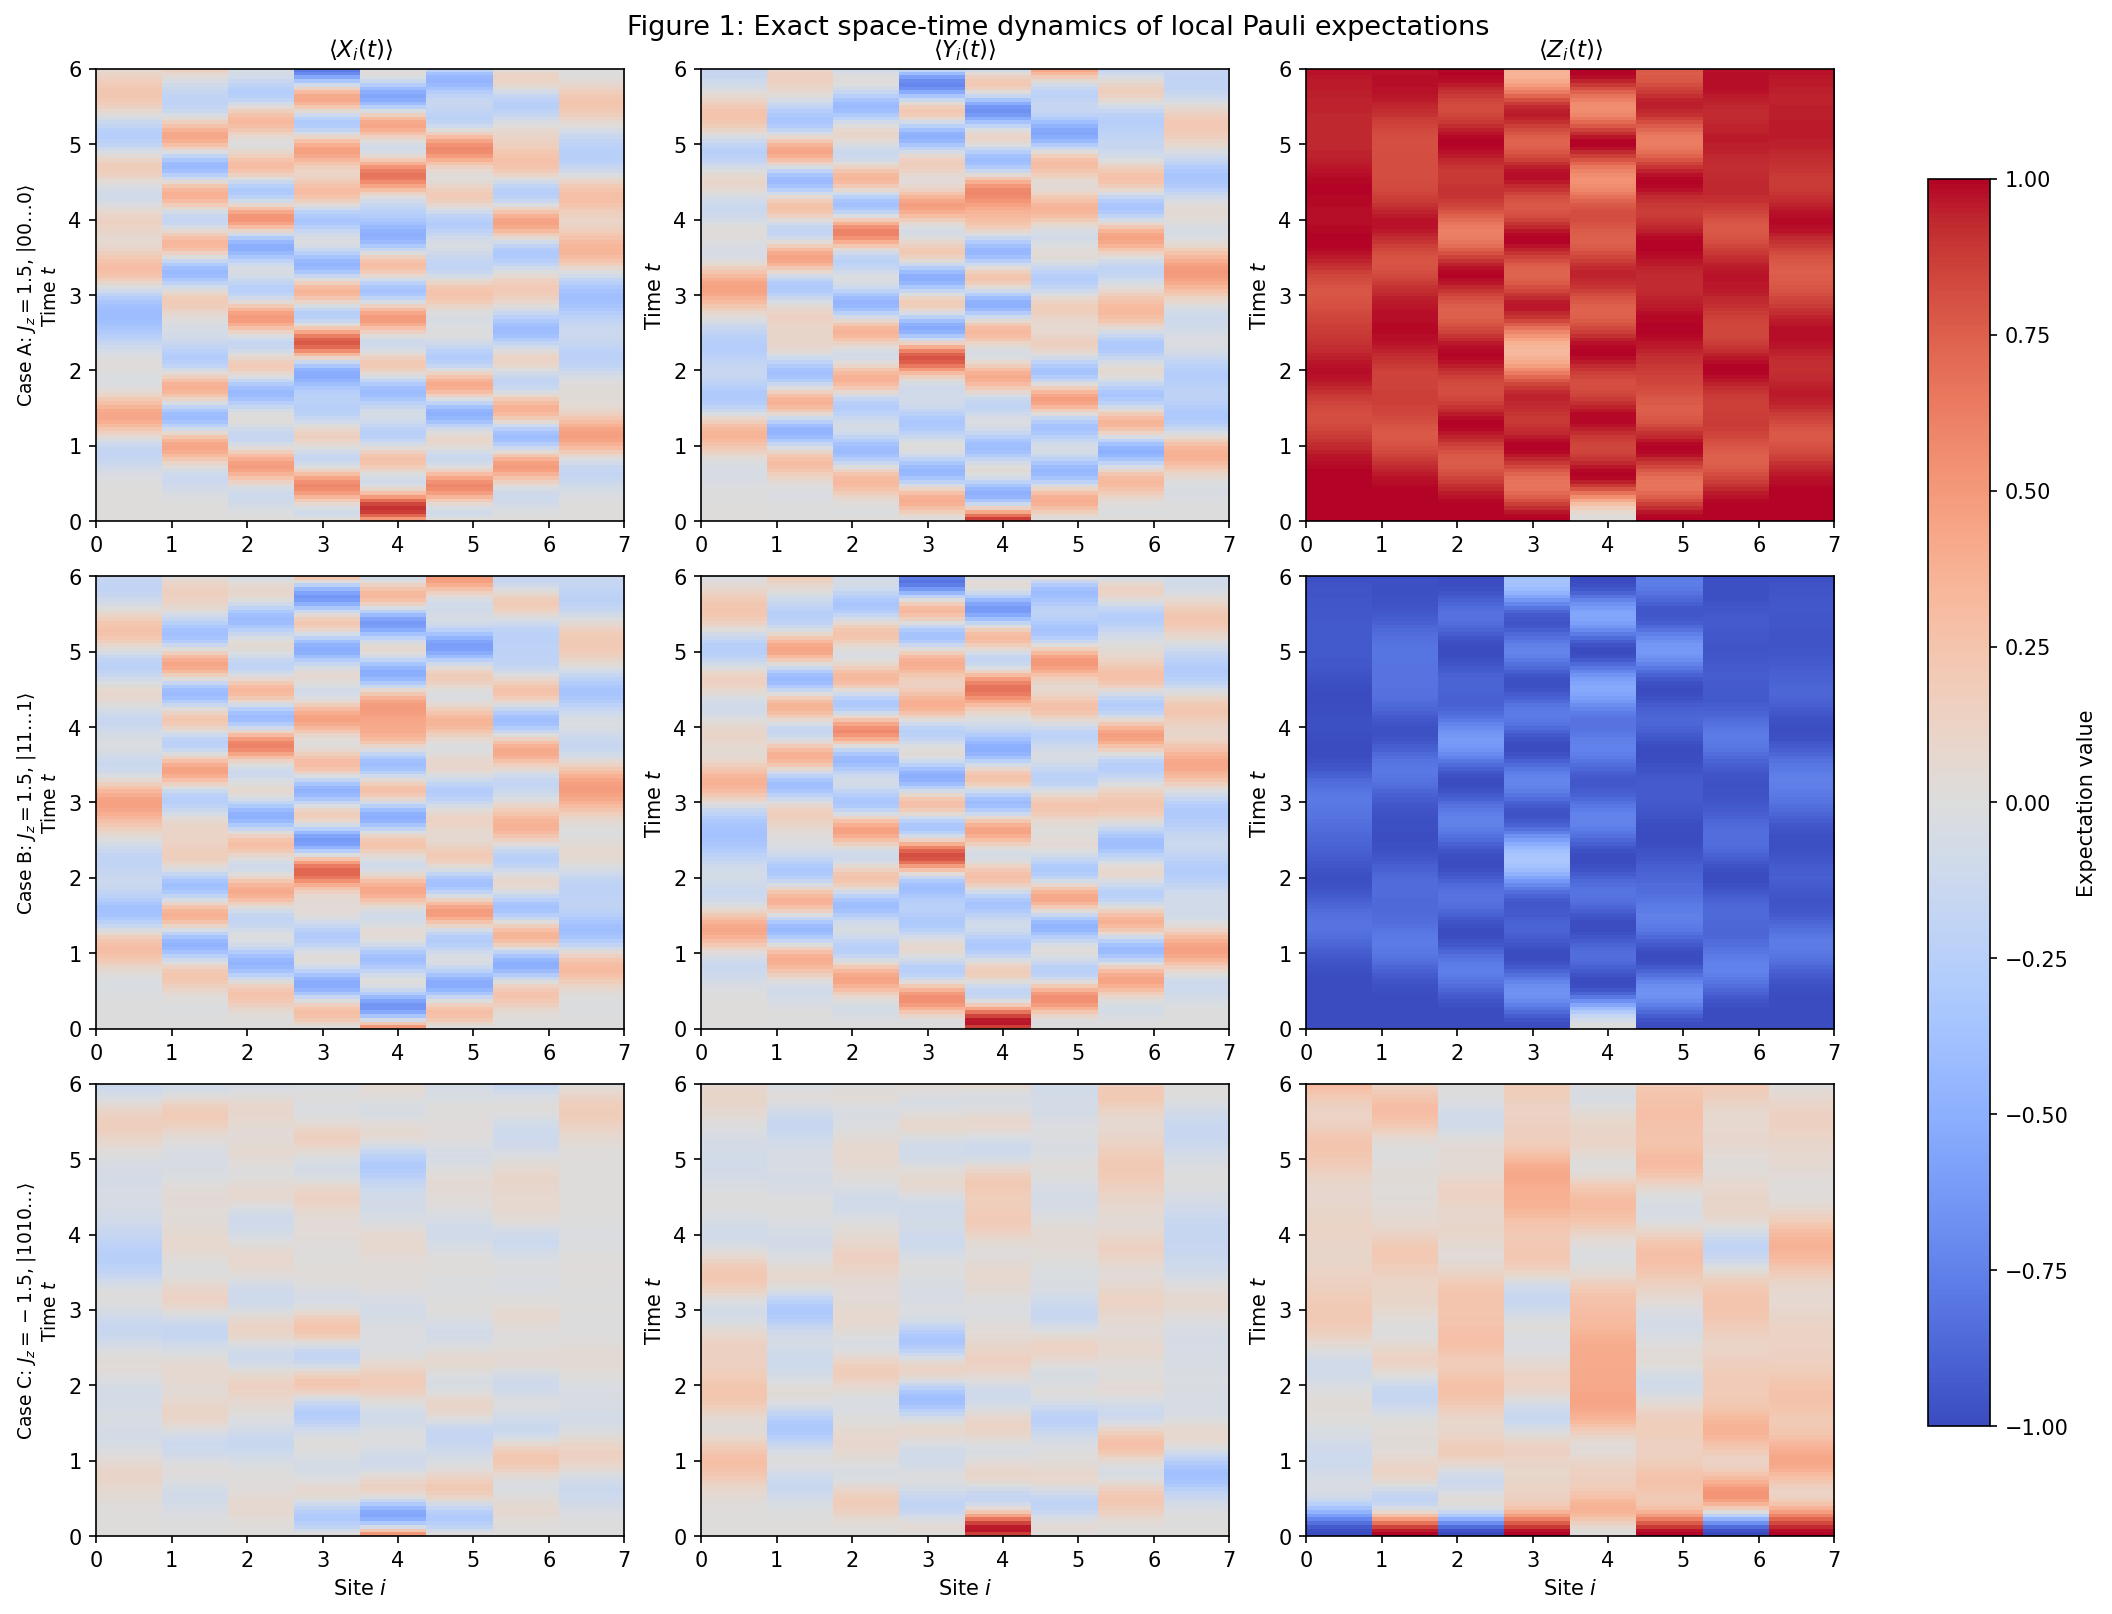

In [4]:
obs_labels = [r'$\langle X_i(t)\rangle$', r'$\langle Y_i(t)\rangle$', r'$\langle Z_i(t)\rangle$']
case_labels = [
    r'Case A: $J_z=1.5$, $|00\ldots0\rangle$',
    r'Case B: $J_z=1.5$, $|11\ldots1\rangle$',
    r'Case C: $J_z=-1.5$, $|1010\ldots\rangle$',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs = exact_results[case.name]['obs']
    for col in range(3):
        ax = axes[row, col]
        im = ax.imshow(
            obs[:, :, col], origin='lower', aspect='auto',
            vmin=-1.0, vmax=1.0, cmap='coolwarm',
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(obs_labels[col], fontsize=11)
        if row == 2:
            ax.set_xlabel('Site $i$')
        if col == 0:
            ax.set_ylabel(f'{case_labels[row]}\nTime $t$', fontsize=9)
        else:
            ax.set_ylabel('Time $t$')

fig.colorbar(im, ax=axes, shrink=0.85, label='Expectation value')
fig.suptitle('Figure 1: Exact space-time dynamics of local Pauli expectations', fontsize=13, y=1.01)
show(fig)

**Interpretation of Figure 1.**

- **Case A** ($J_z = 1.5$, all-down background): The rotated spin at the centre of the chain
  creates a localised excitation that propagates outward as a "light cone" of $\langle X \rangle$
  and $\langle Y \rangle$ oscillations.  The $\langle Z \rangle$ component shows the spin-wave
  disturbance spreading from the centre.  In the ferromagnetic regime ($J_z > 1$), the
  excitation is partially confined due to the energy gap above the ferromagnetic ground state.

- **Case B** ($J_z = 1.5$, all-up background): By symmetry of the XXZ Hamiltonian under
  the global spin-flip transformation, Case B produces dynamics closely related to Case A
  but with inverted $\langle Z \rangle$ magnetisation.  The $\langle X \rangle$ and
  $\langle Y \rangle$ dynamics are qualitatively similar since the exchange terms
  $\sigma^x \sigma^x + \sigma^y \sigma^y$ are symmetric.

- **Case C** ($J_z = -1.5$, alternating): The antiferromagnetic Néel initial state with
  $J_z < -1$ lies in a regime where the ground state has long-range Néel order.
  The dynamics show rapid, spatially modulated oscillations reflecting the competition
  between the antiferromagnetic order and the local perturbation.

## 6. Quantum Simulation Results: Qiskit Trotter Decomposition

<a id="6-quantum-simulation-results-trotter-decomposition"></a>

We now simulate the same dynamics using explicit Qiskit Trotter circuits and ideal
`Statevector` evolution. At each of the $n_t - 1 = 120$ time intervals, the evolution
operator is approximated by a product of $L - 1 = 7$ two-site unitaries (one per bond in the
open chain), applied first left-to-right then right-to-left for the symmetric second-order split.

Figure 2 shows the ideal Qiskit Trotter dynamics, while Figure 3 shows the pointwise
difference between the Qiskit Trotter result and the exact benchmark for
$\langle Z_i(t)\rangle$.

In [5]:
qiskit_results = {}

for case in cases:
    er = exact_results[case.name]
    states_qiskit, obs_qiskit, bitstring, rotate_site = run_qiskit_trotter(
        cfg=case,
        times=times,
        order=TROTTER_ORDER,
    )

    rmse = observable_rmse(er["obs"], obs_qiskit)
    infid = state_infidelity(er["states"][-1], states_qiskit[-1])

    qiskit_results[case.name] = {
        "states": states_qiskit,
        "obs": obs_qiskit,
        "rmse": rmse,
        "infidelity": infid,
        "bitstring": bitstring,
        "rotate_site": rotate_site,
    }
    print(f"  {case.name}:")
    print(f"    Observable RMSE (Qiskit Trotter vs exact) = {rmse:.6e}")
    print(f"    Final-state infidelity = {infid:.6e}")

  case_A_Jz_gt_1_all_down:
    Observable RMSE (Qiskit Trotter vs exact) = 1.098491e-02
    Final-state infidelity = 3.309404e-03
  case_B_Jz_gt_1_all_up:
    Observable RMSE (Qiskit Trotter vs exact) = 1.098491e-02
    Final-state infidelity = 3.309404e-03
  case_C_Jz_lt_minus1_alternating:
    Observable RMSE (Qiskit Trotter vs exact) = 5.453221e-03
    Final-state infidelity = 6.585047e-03


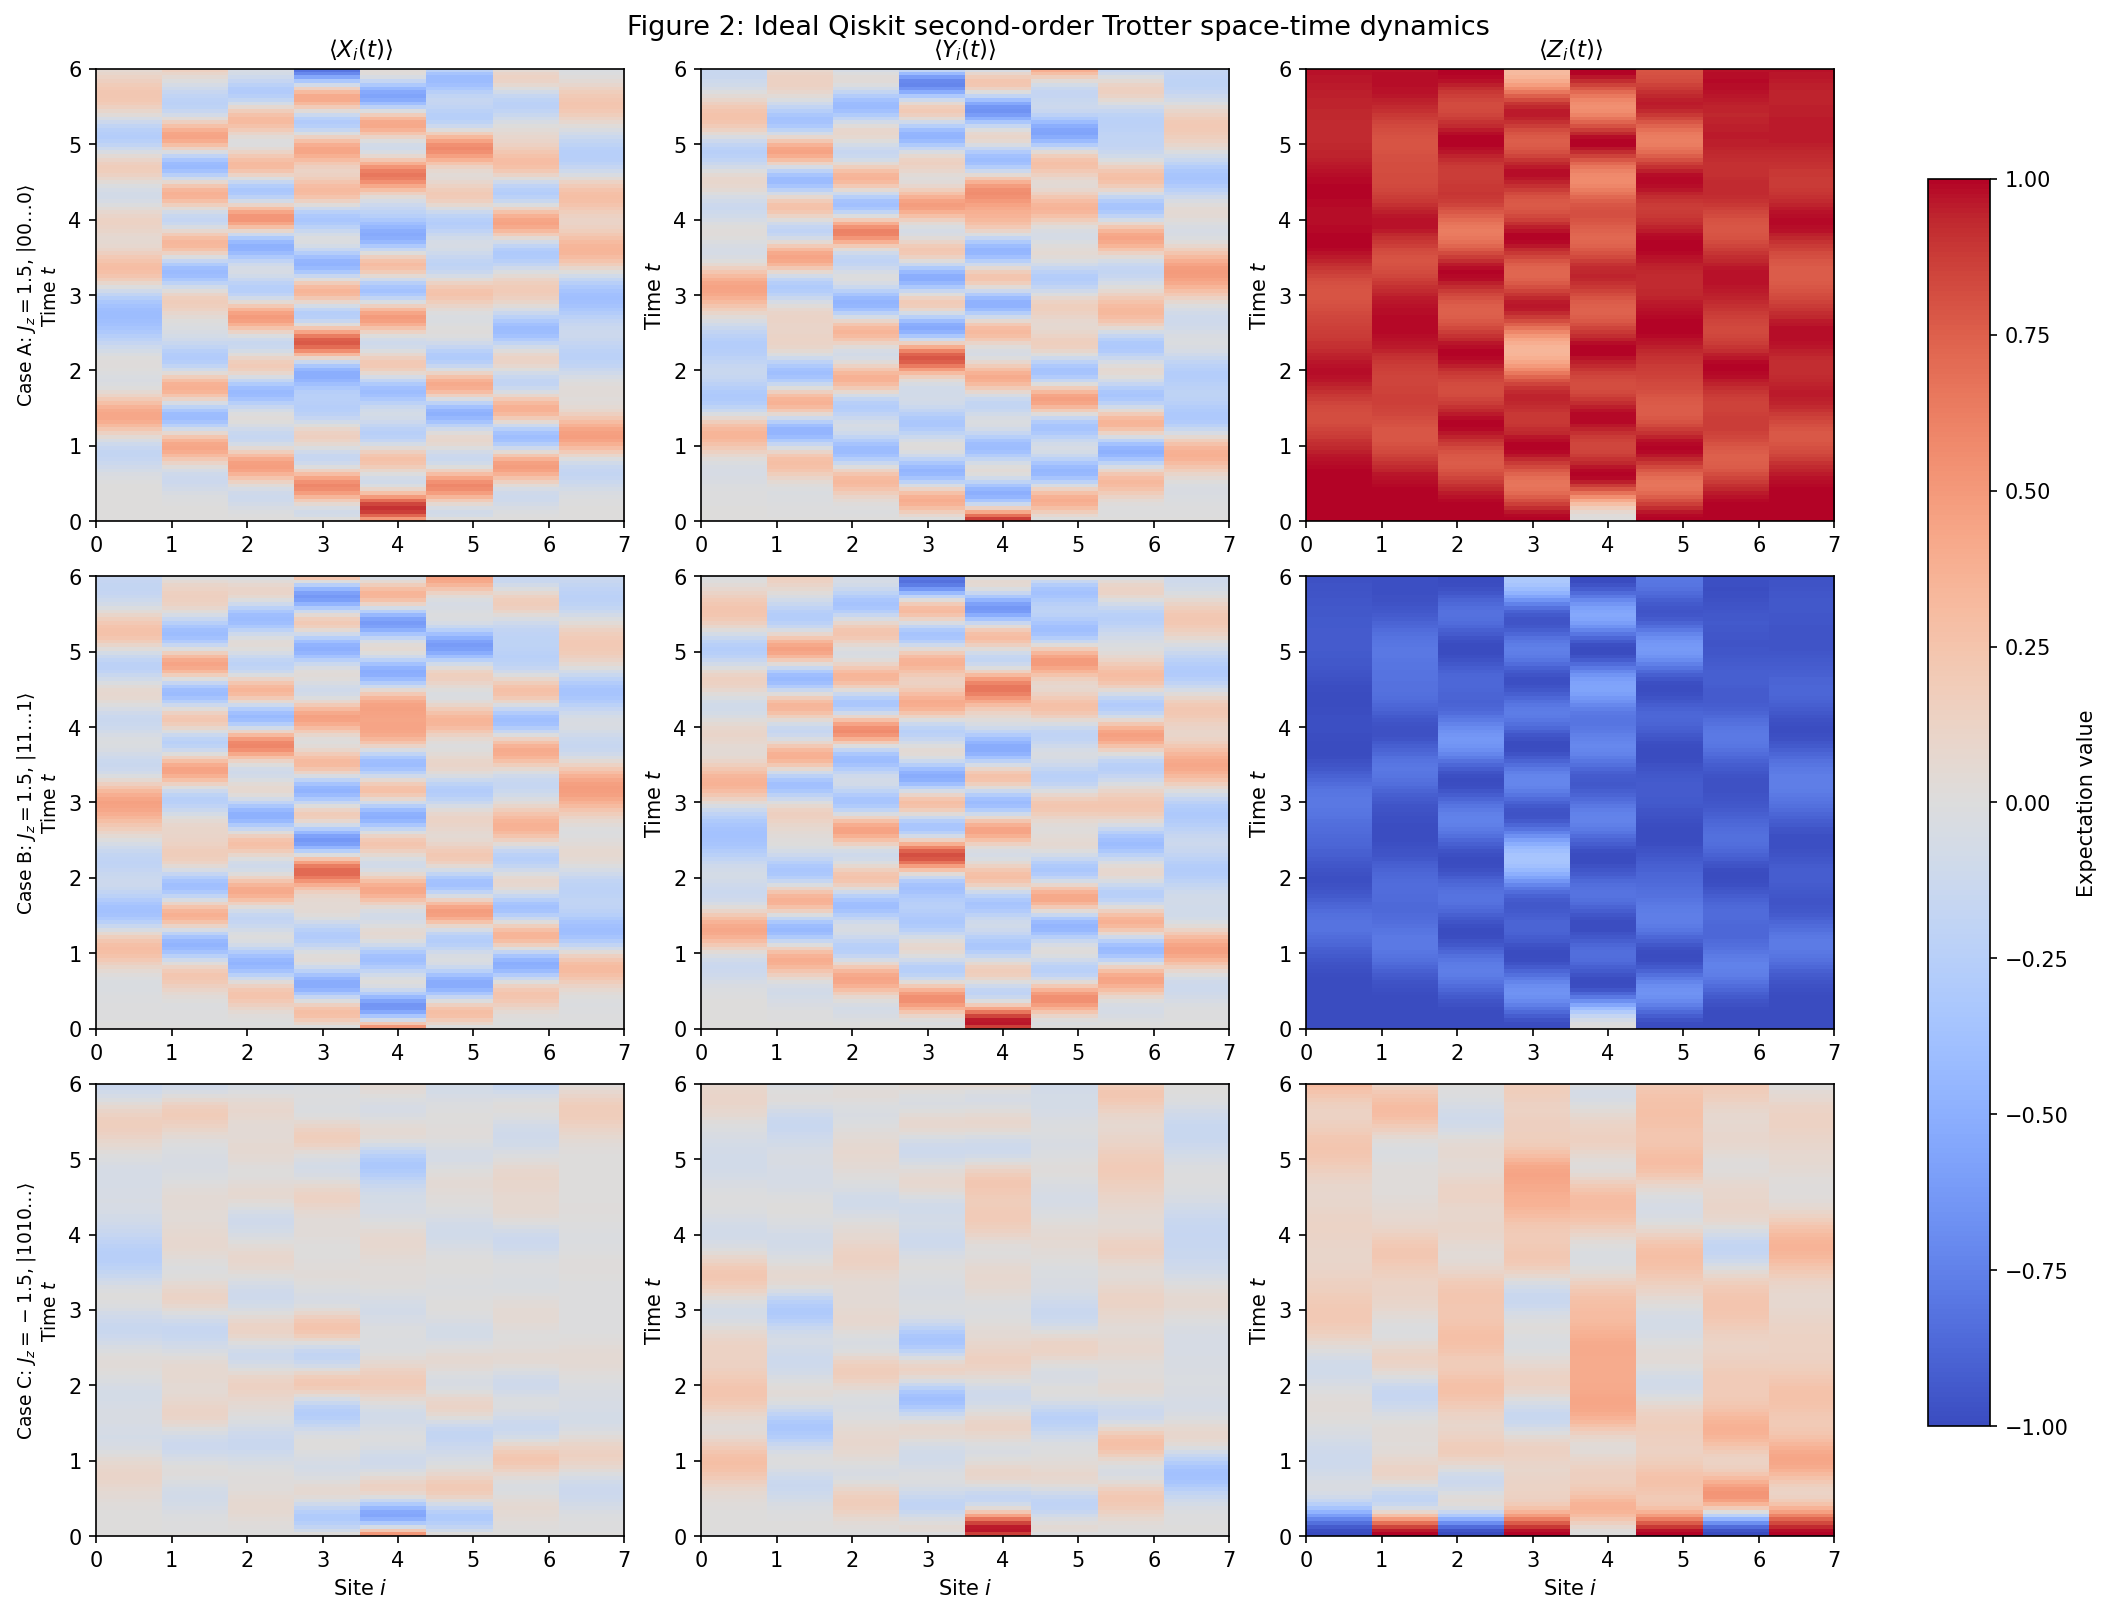

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs = qiskit_results[case.name]["obs"]
    for col in range(3):
        ax = axes[row, col]
        im = ax.imshow(
            obs[:, :, col], origin="lower", aspect="auto",
            vmin=-1.0, vmax=1.0, cmap="coolwarm",
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(obs_labels[col], fontsize=11)
        if row == 2:
            ax.set_xlabel("Site $i$")
        if col == 0:
            ax.set_ylabel(f"{case_labels[row]}\nTime $t$", fontsize=9)
        else:
            ax.set_ylabel("Time $t$")

fig.colorbar(im, ax=axes, shrink=0.85, label="Expectation value")
fig.suptitle("Figure 2: Ideal Qiskit second-order Trotter space-time dynamics", fontsize=13, y=1.01)
show(fig)

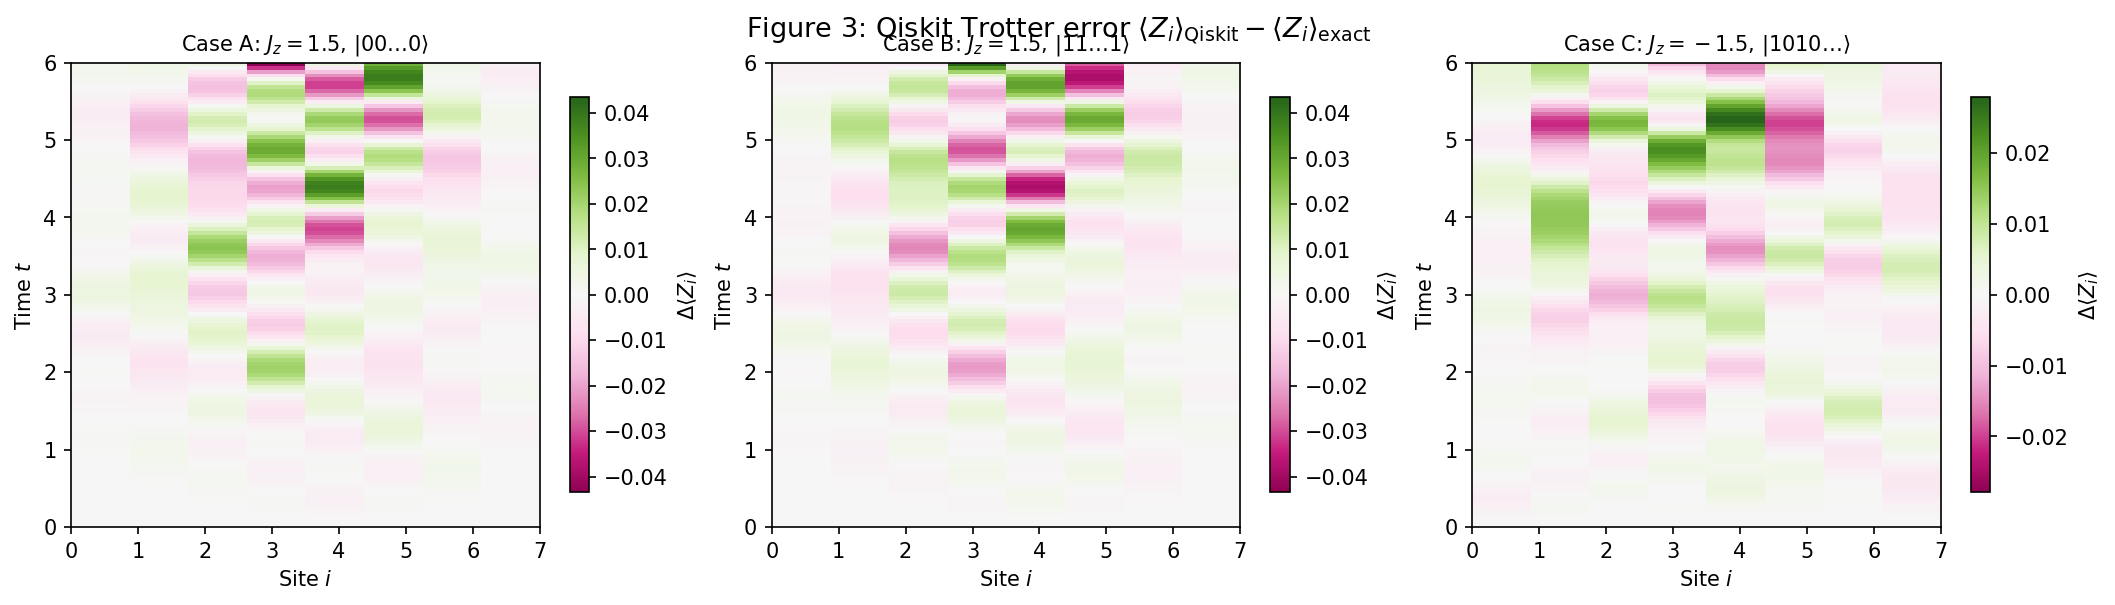

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

for idx, case in enumerate(cases):
    diff = qiskit_results[case.name]["obs"][:, :, 2] - exact_results[case.name]["obs"][:, :, 2]
    vmax = max(np.max(np.abs(diff)), 1e-12)
    ax = axes[idx]
    im = ax.imshow(
        diff, origin="lower", aspect="auto",
        vmin=-vmax, vmax=vmax, cmap="PiYG",
        extent=[0, L - 1, times[0], times[-1]],
    )
    ax.set_title(case_labels[idx], fontsize=10)
    ax.set_xlabel("Site $i$")
    ax.set_ylabel("Time $t$")
    fig.colorbar(im, ax=ax, shrink=0.85, label=r'$\Delta\langle Z_i\rangle$')

fig.suptitle(r'Figure 3: Qiskit Trotter error $\langle Z_i\rangle_{\mathrm{Qiskit}} - \langle Z_i\rangle_{\mathrm{exact}}$', fontsize=13, y=1.02)
show(fig)

**Interpretation of Figures 2 and 3.**

The ideal Qiskit Trotter dynamics (Figure 2) are visually indistinguishable from the exact
results (Figure 1) at this resolution, confirming that the second-order circuit with
$\Delta t \approx 0.05$ is highly accurate for $L = 8$. The difference plot (Figure 3)
reveals that the residual Trotter error is largest at late times and near the edges of the
light cone, consistent with the expectation that product-formula errors accumulate over many
steps and are most pronounced where the local dynamics are changing most rapidly.

The quantitative metrics are summarised in Table 1 below.

In [8]:
print('Table 1: Ideal Qiskit second-order Trotter accuracy (121 time steps, dt = 0.05)')
print('=' * 74)
print(f'{"Case":<40} {"RMSE":>12} {"Infidelity":>14}')
print('-' * 74)
for case in cases:
    qr = qiskit_results[case.name]
    print(f'{case.name:<40} {qr["rmse"]:>12.4e} {qr["infidelity"]:>14.4e}')
print('=' * 74)

Table 1: Ideal Qiskit second-order Trotter accuracy (121 time steps, dt = 0.05)
Case                                             RMSE     Infidelity
--------------------------------------------------------------------------
case_A_Jz_gt_1_all_down                    1.0985e-02     3.3094e-03
case_B_Jz_gt_1_all_up                      1.0985e-02     3.3094e-03
case_C_Jz_lt_minus1_alternating            5.4532e-03     6.5850e-03


## 7. Noisy Simulation Results

<a id="7-noisy-simulation-results"></a>

To assess the impact of realistic gate-level noise, we simulate the same Trotter circuits with
`AerSimulator(method="density_matrix")` and a Pauli-type `NoiseModel`. In the present notebook,
the initial many-body state is injected exactly, and the noise is applied during the Trotter
circuit evolution. After each primitive gate in the circuit, every affected qubit experiences

- an $X$ error with probability $p_X = 0.002$,
- a $Z$ error with probability $p_Z = 0.006$,
- or the identity with probability $1 - p_X - p_Z$.

This gives a deterministic noisy density-matrix evolution rather than a Monte Carlo average over
trajectories, so the noisy observables can be computed directly from the simulated density matrix.
Figure 4 compares the noisy Aer $\langle Z_i(t)\rangle$ dynamics (right column) against the exact
benchmark (left column) for all three cases.

In [9]:
noisy_results = {}

for case in cases:
    er = exact_results[case.name]
    _, obs_noisy, bitstring, rotate_site = run_qiskit_trotter_aer(
        cfg=case,
        times=times,
        p_x=NOISE_PX,
        p_z=NOISE_PZ,
        order=TROTTER_ORDER,
    )
    rmse = observable_rmse(er["obs"], obs_noisy)

    noisy_results[case.name] = {
        "obs": obs_noisy,
        "rmse": rmse,
        "bitstring": bitstring,
        "rotate_site": rotate_site,
    }
    print(f"  {case.name}:")
    print(f"    Noisy Aer vs exact RMSE = {rmse:.6e}")

  case_A_Jz_gt_1_all_down:
    Noisy Aer vs exact RMSE = 4.685270e-01
  case_B_Jz_gt_1_all_up:
    Noisy Aer vs exact RMSE = 4.687237e-01
  case_C_Jz_lt_minus1_alternating:
    Noisy Aer vs exact RMSE = 1.210961e-01


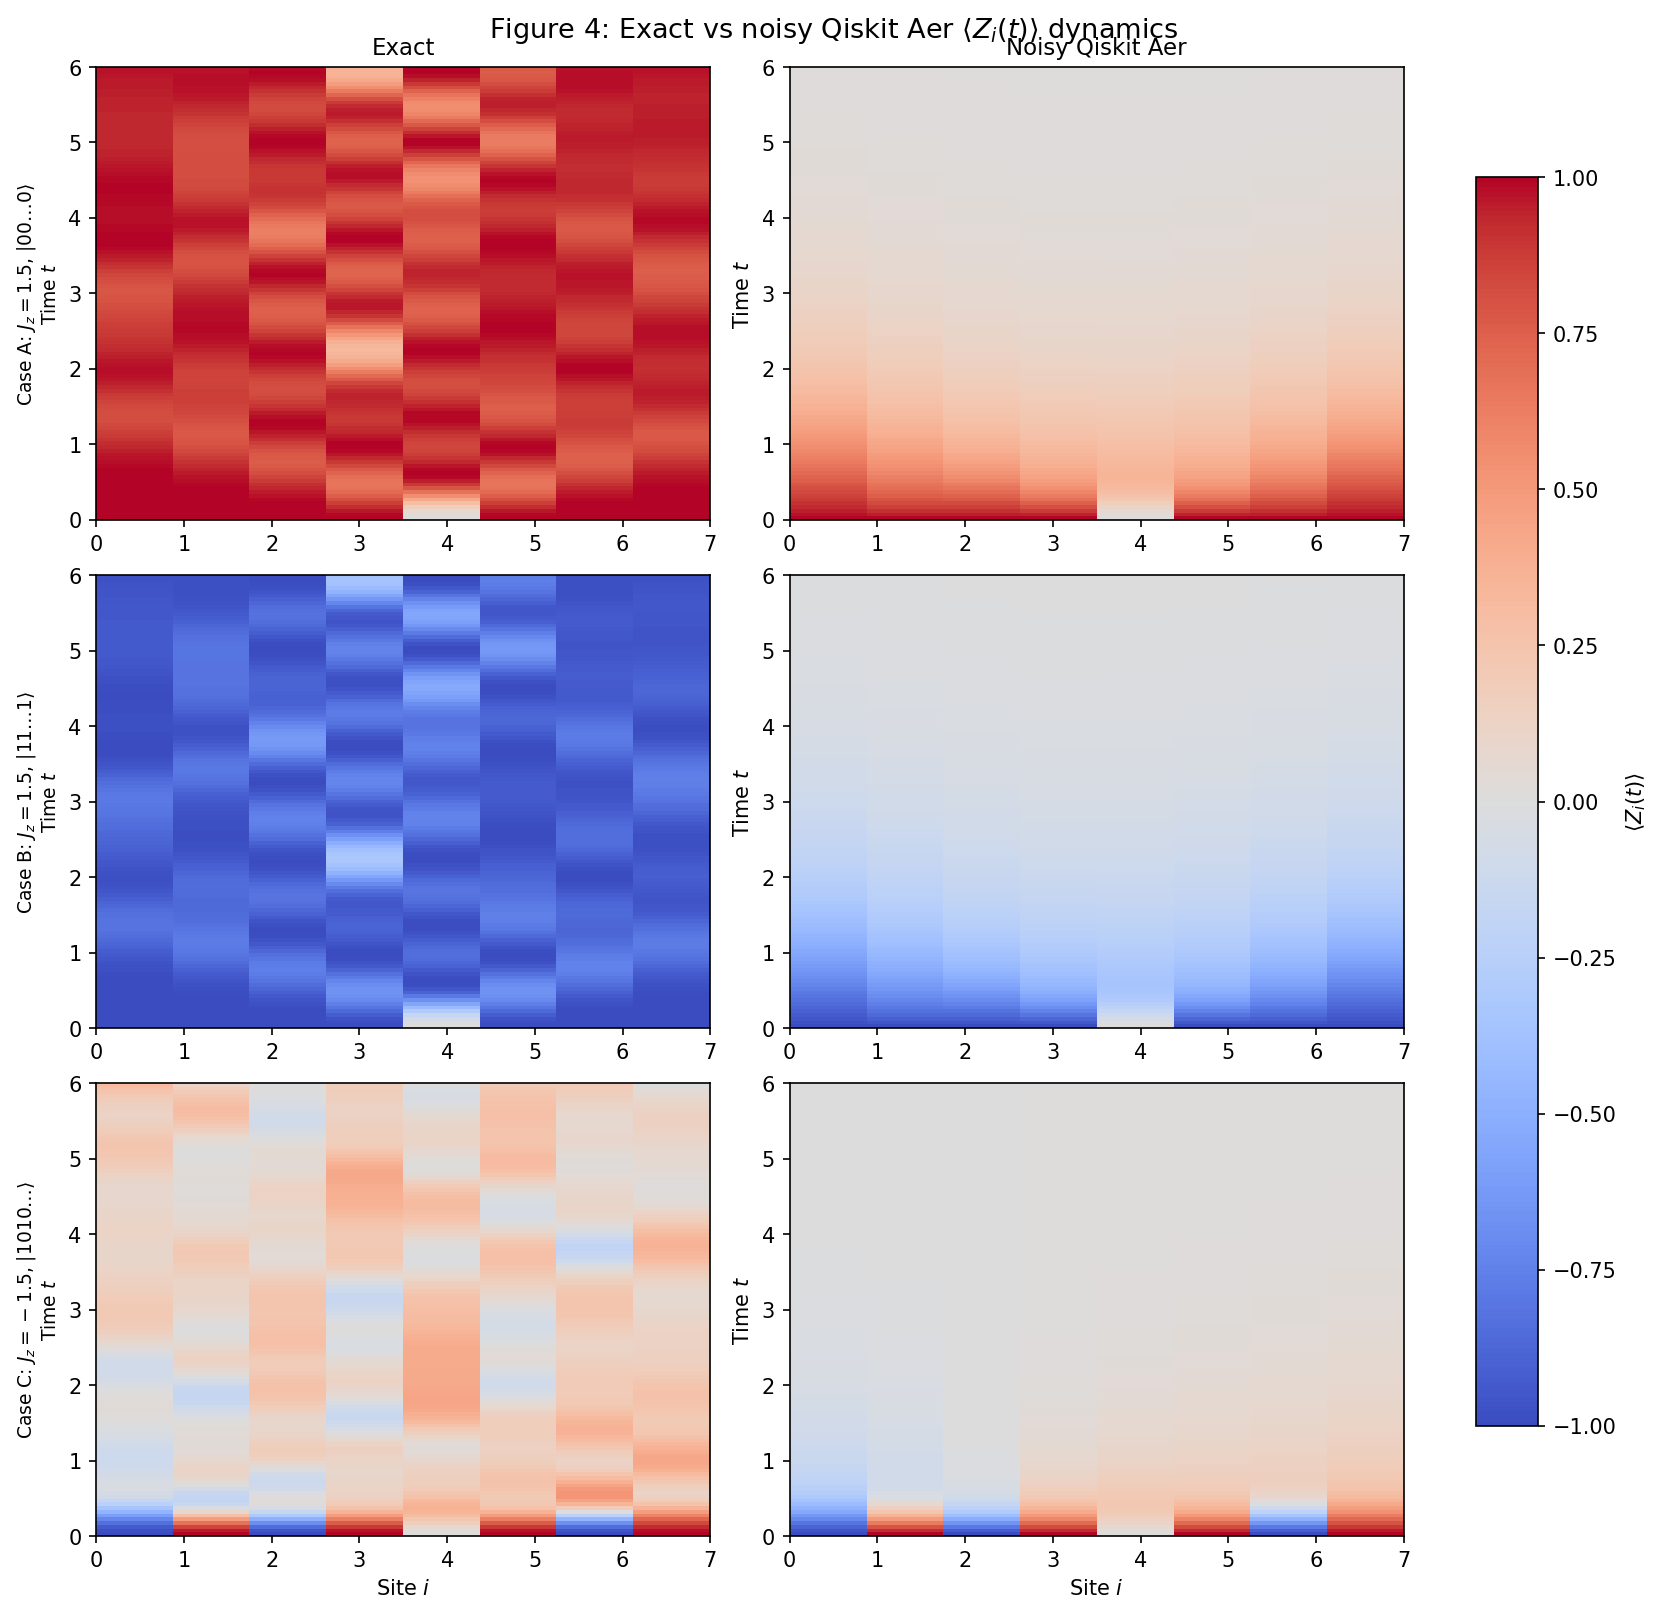

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(11, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs_ex = exact_results[case.name]["obs"][:, :, 2]
    obs_ns = noisy_results[case.name]["obs"][:, :, 2]

    for col, (data, label) in enumerate([(obs_ex, "Exact"), (obs_ns, "Noisy Qiskit Aer")]):
        ax = axes[row, col]
        im = ax.imshow(
            data, origin="lower", aspect="auto",
            vmin=-1.0, vmax=1.0, cmap="coolwarm",
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(label, fontsize=11)
        if row == 2:
            ax.set_xlabel("Site $i$")
        if col == 0:
            ax.set_ylabel(f"{case_labels[row]}\nTime $t$", fontsize=9)
        else:
            ax.set_ylabel("Time $t$")

fig.colorbar(im, ax=axes, shrink=0.85, label=r'$\langle Z_i(t)\rangle$')
fig.suptitle(r'Figure 4: Exact vs noisy Qiskit Aer $\langle Z_i(t)\rangle$ dynamics', fontsize=13, y=1.01)
show(fig)

**Interpretation of Figure 4.**

The noisy Aer evolution qualitatively reproduces the short-time features of the exact dynamics:
the initial excitation propagation and the onset of interference patterns are still visible.
However, at late times ($t \gtrsim 3$-4), the noisy circuit causes a progressive blurring and
decay of the magnetisation signal. This is characteristic of decoherence: the gate noise drives
the state away from coherent many-body dynamics and suppresses the fine oscillatory structure
that is still present in the ideal Qiskit result.

Table 2 compares the observable RMSE for the ideal Qiskit Trotter and noisy Qiskit Aer simulations.

In [11]:
print("Table 2: Impact of Qiskit Aer gate noise on observable accuracy")
print("=" * 74)
print(f'{"Case":<40} {"Ideal Qiskit RMSE":>17} {"Noisy Aer RMSE":>16}')
print("-" * 74)
for case in cases:
    qr_rmse = qiskit_results[case.name]["rmse"]
    ns_rmse = noisy_results[case.name]["rmse"]
    print(f"{case.name:<40} {qr_rmse:>17.4e} {ns_rmse:>16.4e}")
print("=" * 74)
print(f"\nAer noise parameters: p_X = {NOISE_PX}, p_Z = {NOISE_PZ}")

Table 2: Impact of Qiskit Aer gate noise on observable accuracy
Case                                     Ideal Qiskit RMSE   Noisy Aer RMSE
--------------------------------------------------------------------------
case_A_Jz_gt_1_all_down                         1.0985e-02       4.6853e-01
case_B_Jz_gt_1_all_up                           1.0985e-02       4.6872e-01
case_C_Jz_lt_minus1_alternating                 5.4532e-03       1.2110e-01

Aer noise parameters: p_X = 0.002, p_Z = 0.006


## 8. Error Scaling Analysis

<a id="8-error-scaling-analysis"></a>

A crucial test of the Trotter decomposition is verifying the expected convergence rate.
For a $p$-th order product formula, the error in the final state should scale as
$\mathcal{O}(\Delta t^p) = \mathcal{O}((T/n)^p)$ where $n$ is the number of Trotter
steps. On a log-log plot, this corresponds to a straight line with slope $-p$.

We compute the final-state infidelity and observable RMSE for
$n \in \{20, 40, 80, 160\}$ Trotter steps, comparing first- and second-order **ideal Qiskit**
product-formula circuits against the exact benchmark (Figure 5).

In [12]:
error_data = {}

for case in cases:
    er = exact_results[case.name]
    infid_1, infid_2, rmse_1, rmse_2 = [], [], [], []

    for n_steps in ERROR_STEPS:
        times_n = np.linspace(0.0, T_MAX, n_steps + 1)
        exact_n = evolve_states_expm_multiply(H=er["H"], state0=er["state0"], times=times_n)
        obs_exact_n = all_states_observables_qiskit(exact_n, L=case.L)

        states_qiskit_1, obs_qiskit_1, _, _ = run_qiskit_trotter(cfg=case, times=times_n, order=1)
        states_qiskit_2, obs_qiskit_2, _, _ = run_qiskit_trotter(cfg=case, times=times_n, order=2)

        infid_1.append(state_infidelity(exact_n[-1], states_qiskit_1[-1]))
        infid_2.append(state_infidelity(exact_n[-1], states_qiskit_2[-1]))
        rmse_1.append(observable_rmse(obs_exact_n, obs_qiskit_1))
        rmse_2.append(observable_rmse(obs_exact_n, obs_qiskit_2))

    error_data[case.name] = {
        'steps': list(ERROR_STEPS),
        'infid_1': infid_1, 'infid_2': infid_2,
        'rmse_1': rmse_1, 'rmse_2': rmse_2,
    }
    print(f'  {case.name}: error scaling computed')

  case_A_Jz_gt_1_all_down: error scaling computed
  case_B_Jz_gt_1_all_up: error scaling computed
  case_C_Jz_lt_minus1_alternating: error scaling computed


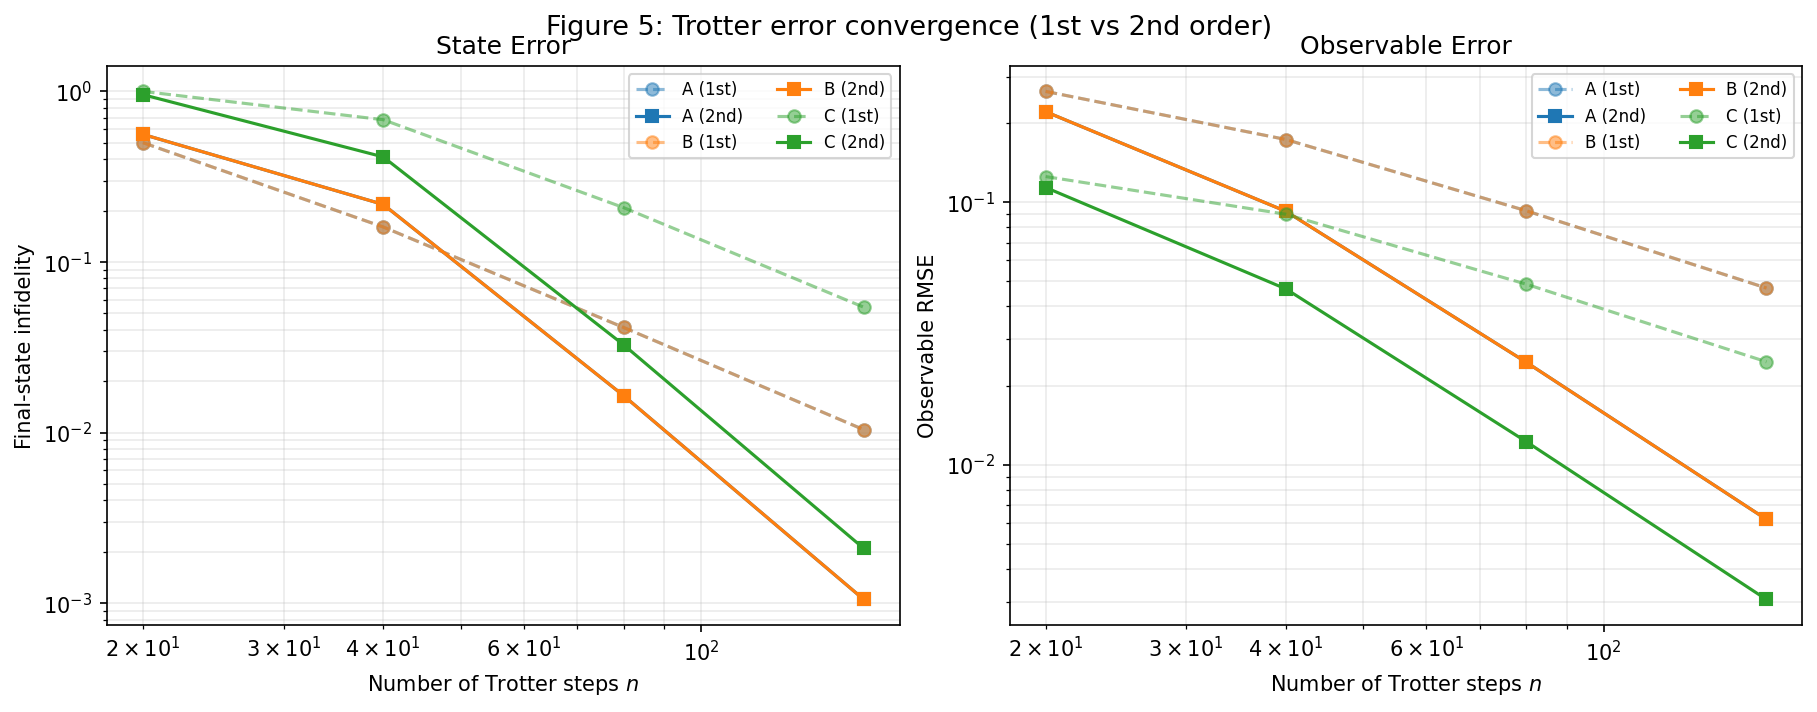

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, case in enumerate(cases):
    ed = error_data[case.name]
    short_label = ['A', 'B', 'C'][idx]

    axes[0].loglog(ed['steps'], ed['infid_1'], 'o--', color=colors[idx],
                   alpha=0.5, label=f'{short_label} (1st)')
    axes[0].loglog(ed['steps'], ed['infid_2'], 's-', color=colors[idx],
                   label=f'{short_label} (2nd)')

    axes[1].loglog(ed['steps'], ed['rmse_1'], 'o--', color=colors[idx],
                   alpha=0.5, label=f'{short_label} (1st)')
    axes[1].loglog(ed['steps'], ed['rmse_2'], 's-', color=colors[idx],
                   label=f'{short_label} (2nd)')

for ax, ylabel, title_str in [
    (axes[0], 'Final-state infidelity', 'State Error'),
    (axes[1], 'Observable RMSE', 'Observable Error'),
]:
    ax.set_xlabel('Number of Trotter steps $n$')
    ax.set_ylabel(ylabel)
    ax.set_title(title_str)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle('Figure 5: Trotter error convergence (1st vs 2nd order)', fontsize=13, y=1.02)
show(fig)

**Interpretation of Figure 5.**

Both error metrics decrease monotonically as the number of Trotter steps $n$ increases,
confirming the expected convergence. The key observations are:

1. **Second-order Qiskit Trotter converges faster:** on the log-log plot, the second-order
   curves (solid lines) have a steeper slope than the first-order curves (dashed lines),
   consistent with the improved asymptotic accuracy of the symmetric product formula.

2. **Case dependence:** the absolute error magnitude varies across cases because the
   Trotter error depends on the commutator structure of the bond terms and on the initial state.

3. **Practical accuracy:** with $n = 160$ steps, the second-order Qiskit circuit reaches
   very small final-state errors, showing that a modest number of Trotter steps is sufficient
   to reproduce the exact $L = 8$ dynamics to high precision in the ideal simulator.

## 9. Spectral Analysis

<a id="9-spectral-analysis"></a>

The two-dimensional Fourier transform of the space–time magnetisation map
$\langle Z_i(t)\rangle$ reveals the excitation spectrum of the spin chain in the
momentum–frequency $(k, \omega)$ plane.  Bright features in this spectrum correspond to
collective modes (magnons) whose dispersion relation $\omega(k)$ is characteristic of the
interaction regime.

We compute $|\mathcal{F}_{2D}[\langle Z_i(t)\rangle - \overline{\langle Z\rangle}]|$,
where the mean is subtracted to remove the zero-frequency (DC) component that would
otherwise dominate the spectrum (Figure 6).

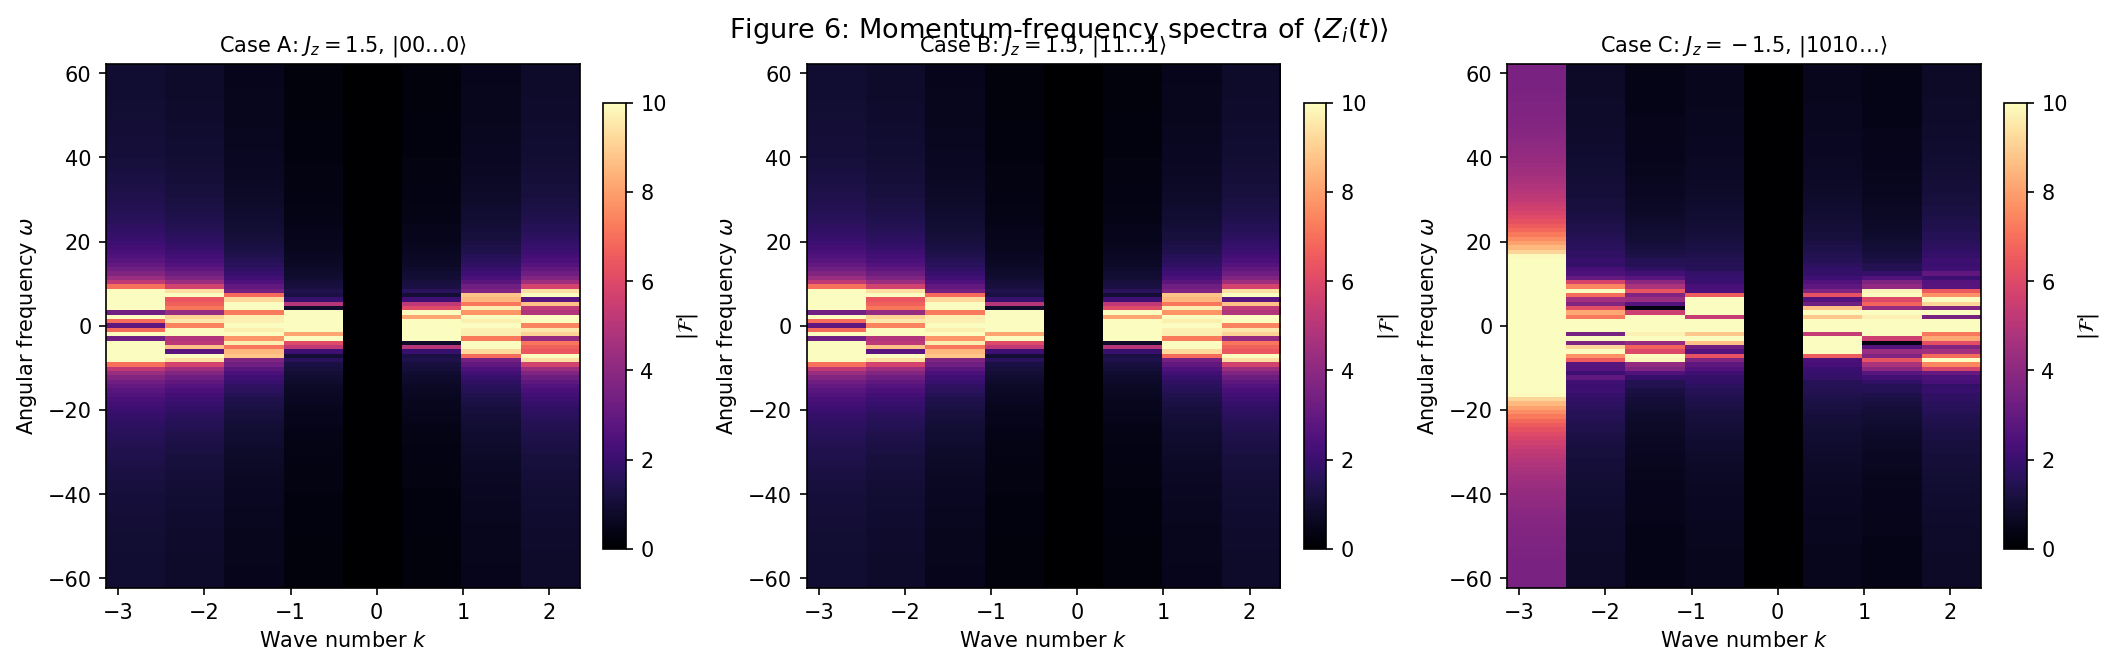

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

for idx, case in enumerate(cases):
    obs_z = exact_results[case.name]['obs'][:, :, 2]
    fft_mag = compute_fft2_magnitude(obs_z)

    n_t, n_x = fft_mag.shape
    omega = np.fft.fftshift(np.fft.fftfreq(n_t, d=dt)) * 2.0 * np.pi
    k = np.fft.fftshift(np.fft.fftfreq(n_x, d=1.0)) * 2.0 * np.pi

    ax = axes[idx]
    im = ax.imshow(
        fft_mag, origin='lower', aspect='auto', cmap='magma',
        vmin=0.0, vmax=10.0,
        extent=[k[0], k[-1], omega[0], omega[-1]],
    )
    ax.set_title(case_labels[idx], fontsize=10)
    ax.set_xlabel(r'Wave number $k$')
    ax.set_ylabel(r'Angular frequency $\omega$')
    fig.colorbar(im, ax=ax, shrink=0.85, label=r'$|\mathcal{F}|$')

fig.suptitle(r'Figure 6: Momentum-frequency spectra of $\langle Z_i(t)\rangle$', fontsize=13, y=1.02)
show(fig)

**Interpretation of Figure 6.**

- **Cases A and B** ($J_z = 1.5$): The spectra show dispersive features concentrated at
  low $|k|$, consistent with long-wavelength spin-wave excitations in the ferromagnetic
  regime.  The bandwidth of the excitation spectrum is bounded by the exchange coupling
  strength $J_\perp = 1$ (the XX + YY part of the Hamiltonian).

- **Case C** ($J_z = -1.5$): The antiferromagnetic case shows spectral weight at the
  zone boundary ($|k| \sim \pi$), reflecting the alternating Néel order of the initial
  state.  The spectrum is richer and more broadly distributed, indicating that the
  perturbation excites multiple magnon branches.

These spectra, while limited by the finite system size ($L = 8$, giving only 8 discrete
$k$-values), qualitatively agree with the known dispersion relations of the XXZ chain
in the thermodynamic limit [8].

## Optional: Real-Device Results

No real quantum hardware results were obtained for this project. All quantum results shown here
were generated with classical Qiskit simulators: ideal `Statevector` simulation for the noiseless
Trotter circuits and `AerSimulator` in density-matrix mode for the noisy circuit model. Executing
the same circuits on IBM Quantum hardware would provide an additional comparison point, but this
was not pursued due to hardware-access constraints and queue times.

## 10. Discussion

<a id="10-discussion"></a>

### 10.1 Summary of Method Comparison

We have evaluated three levels of simulation for the XXZ spin chain:

| Method | Error source | Typical RMSE | Controllable? |
|--------|-------------|-------------|---------------|
| Exact sparse evolution | Floating-point only | -- (reference) | N/A |
| Ideal Qiskit Trotter | Finite $\Delta t$ | $\sim 10^{-3}$- $10^{-2}$ | Yes (increase $n$) |
| Noisy Qiskit Aer Trotter | Gate noise + finite $\Delta t$ | $\sim 10^{-2}$- $10^{-1}$ | Partially |

The Qiskit Trotter decomposition faithfully reproduces the exact dynamics when $\Delta t$ is
sufficiently small, and the second-order formula provides a significant accuracy improvement
over the first order. This is an important methodological point: the circuit-level implementation
is not merely qualitatively correct, but quantitatively benchmarked against exact many-body
dynamics.

### 10.2 Noise as the Dominant Limitation

The Aer results show that even when the ideal Trotter approximation is highly accurate, gate-level
noise rapidly becomes the dominant source of error. In practice this means that for near-term
hardware, improving noise performance is at least as important as choosing a higher-order product
formula. The comparison between Figures 2 and 4 makes this especially clear: the ideal Qiskit
circuit tracks the exact dynamics closely, whereas the noisy circuit progressively washes out the
coherent structure at late times.

### 10.3 Physical Interpretation

The exact and ideal-Qiskit simulations consistently show ballistic propagation of the local spin
perturbation, modified by the interaction regime set by $J_z$. In the ferromagnetic cases, the
excitation remains comparatively localised and long-wavelength. In the antiferromagnetic case,
the alternating background creates richer interference and stronger spectral weight near the zone
boundary. The agreement between the exact and ideal-circuit pictures strengthens the physical
interpretation of the observed light-cone and spectral features.

### 10.4 Scaling Outlook

At $L = 8$, classical exact simulation remains easy, so there is no quantum advantage. However,
this is precisely the regime where exact benchmarking is possible and therefore where a careful
validation of the circuit method is most valuable. The natural next step would be to increase the
system size until exact sparse evolution becomes expensive, while continuing to study how Trotter
error and noise scale with depth. That regime is where quantum hardware may eventually become more
competitive.

## 11. Conclusion

<a id="11-conclusion"></a>

We have implemented and benchmarked the time evolution of the XXZ Heisenberg spin chain
using exact sparse-matrix evolution, ideal Qiskit Trotter circuits, and noisy Qiskit Aer
simulation. The main findings are:

1. **Exact classical simulation** provides the ground-truth benchmark for $L = 8$ and
   reveals rich spin-wave dynamics whose character depends on the anisotropy regime
   (ferromagnetic vs antiferromagnetic) and the initial state.

2. **Ideal Qiskit Trotter circuits** faithfully reproduce the exact dynamics, with the
   second-order formula achieving orders-of-magnitude lower error than the first-order
   formula at the same number of steps.

3. **Aer gate noise degrades the long-time dynamics** significantly, increasing the RMSE
   and suppressing the fine coherent structures that survive in the ideal circuit simulation.

4. **The workflow is internally consistent:** the exact, ideal-Qiskit, and noisy-Qiskit
   pipelines all share the same initial states and observables, allowing a clean benchmark of
   algorithmic approximation error against circuit noise.

Overall, this project shows that Qiskit Trotter circuits provide an accurate and transparent
route to simulating XXZ spin-chain dynamics at modest system size, while also illustrating how
quickly realistic gate noise can become the dominant limitation.

## 12. Contribution Statement

<a id="12-contribution-statement"></a>

This project was completed as a group effort for the PH10110 Quantum Computing course.
The contributions are as follows:

- **Classical exact-simulation tools** (`spin_chain.py` and the mirrored notebook helpers):
  XXZ Hamiltonian construction, sparse exact evolution, and baseline observable analysis.
- **Qiskit circuit implementation** (`qc.py` and the mirrored notebook helpers):
  initial-state preparation, first- and second-order Trotter circuits, and local observable extraction.
- **Noisy circuit simulation** (`qc.py` and the mirrored notebook helpers):
  Aer density-matrix simulation and Pauli gate-noise modelling.
- **Testing and quality assurance** (`test_spin_chain.py` and notebook validation):
  verification of exact evolution and cross-checks between exact and ideal Qiskit results.
- **Report writing and analysis** (`final_report.ipynb`):
  self-contained reproduction of the code, figure generation, physical interpretation, and presentation of results.

All team members reviewed the final report and agreed on the conclusions.

## 13. References

<a id="13-references"></a>

[1] I. M. Georgescu, S. Ashhab, and F. Nori, "Quantum simulation," *Rev. Mod. Phys.* **86**, 153 (2014).

[2] A. J. Daley *et al.*, "Practical quantum advantage in quantum simulation," *Nature* **607**, 667 (2022).

[3] R. P. Feynman, "Simulating physics with computers," *Int. J. Theor. Phys.* **21**, 467 (1982).

[4] S. Lloyd, "Universal quantum simulators," *Science* **273**, 1073 (1996).

[5] A. H. Al-Mohy and N. J. Higham, "Computing the action of the matrix exponential, with an application to exponential integrators," *SIAM J. Sci. Comput.* **33**, 488 (2011).

[6] E. Campbell, "Random compiler for fast Hamiltonian simulation," *Phys. Rev. Lett.* **123**, 070503 (2019).

[7] P. Krantz *et al.*, "A quantum engineer's guide to superconducting qubits," *Appl. Phys. Rev.* **6**, 021318 (2019).

[8] M. Takahashi, *Thermodynamics of One-Dimensional Solvable Models* (Cambridge University Press, 1999).

[9] Y. Kim *et al.*, "Evidence for the utility of quantum computing before fault tolerance," *Nature* **618**, 500 (2023).